In [47]:
from pathlib import Path
import sys

import gerrychain
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))
from pipeline import calculate_metrics as metrics

sns.set_theme(style="whitegrid", context="notebook")


csv_path = Path("../outputs/tracts_in_cbsa_2020-2010-2000-1990-1980_years_march_2020_vintage/white_black.csv")

In [81]:
X_COL = "BLACK"
Y_COL = "WHITE"
TOT_COL = "TOTPOP"

N_AREAS = 100
N_PERMUTATIONS = 500
RANDOM_SEED = 202607

# Keeping the sampled graphs modest makes interactive reruns quick.
MIN_NODES = 25
MAX_NODES = 1000

metric_columns = [
    "half_edge_lam_0_angle_1",
    "half_edge_lam_1_angle_1",
    "half_edge_lam_10_angle_1",
    "half_edge_lam_lim_angle_1",
    "moran_share",
]
metric_labels = {
    "half_edge_lam_0_angle_1": "Half Edge, lambda=0",
    "half_edge_lam_1_angle_1": "Half Edge, lambda=1",
    "half_edge_lam_10_angle_1": "Half Edge, lambda=10",
    "half_edge_lam_lim_angle_1": "Half Edge, lambda=infinity",
    "moran_share": "Moran, share",
}

rng = np.random.default_rng(RANDOM_SEED)

## Choose a few graphs

The CSV has one row per study-area graph. This samples a few manageable tract graphs, then loads the graph JSON referenced by each row.

In [82]:
summary = pd.read_csv(csv_path)
summary["year"] = summary["filename"].str.extract(r"study_areas/(\d{4})/").astype(int)
summary["cbsa"] = summary["filename"].str.extract(r"tracts_in_cbsa_(\d+)_")

candidate_rows = summary[
    summary["total_nodes"].between(MIN_NODES, MAX_NODES)
    & (summary["total_edges"] > 0)
    & (summary["total_black"] > 0)
    & (summary["total_white"] > 0)
].copy()

sample_rows = (
    candidate_rows.sample(n=min(N_AREAS, len(candidate_rows)), random_state=RANDOM_SEED)
    .sort_values(["year", "cbsa"])
    .reset_index(drop=True)
)
sample_rows["area_key"] = sample_rows["year"].astype(str) + " CBSA " + sample_rows["cbsa"]

sample_rows[
    [
        "area_key",
        "total_nodes",
        "total_edges",
        "total_black",
        "total_white",
        "half_edge_lam_1_angle_1",
        "moran",
        "filename",
    ]
]

,area_key,total_nodes,total_edges,total_black,total_white,half_edge_lam_1_angle_1,moran,filename
0,1980 CBSA 12980,40,97,13469,124353,0.579975,0.234237,study_areas/1980/tracts_in_cbsa_12980_1980_mar...
1,1980 CBSA 15940,91,234,23953,374660,0.570631,0.516403,study_areas/1980/tracts_in_cbsa_15940_1980_mar...
2,1980 CBSA 17980,67,174,82674,147585,0.586033,0.286377,study_areas/1980/tracts_in_cbsa_17980_1980_mar...
3,1980 CBSA 22900,38,93,6105,147441,0.536239,0.349252,study_areas/1980/tracts_in_cbsa_22900_1980_mar...
4,1980 CBSA 23420,109,272,24557,316895,0.651677,0.663035,study_areas/1980/tracts_in_cbsa_23420_1980_mar...
...,...,...,...,...,...,...,...,...
95,2020 CBSA 41940,420,1119,42627,575493,0.518298,0.668416,study_areas/2020/tracts_in_cbsa_41940_2020_mar...
96,2020 CBSA 42140,57,147,1221,67861,0.502754,0.106950,study_areas/2020/tracts_in_cbsa_42140_2020_mar...
97,2020 CBSA 43420,38,93,4371,68256,0.514448,0.370360,study_areas/2020/tracts_in_cbsa_43420_2020_mar...
98,2020 CBSA 46060,267,705,36254,536868,0.517135,0.510094,study_areas/2020/tracts_in_cbsa_46060_2020_mar...


<Axes: xlabel='total_nodes', ylabel='Count'>

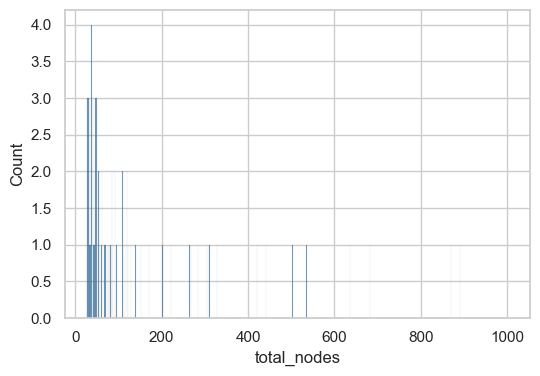

In [83]:
# histogram of number of nodes in the sampled areas
plt.figure(figsize=(6, 4))
sns.histplot(
    data=sample_rows,
    x="total_nodes",
    bins=range(MIN_NODES, MAX_NODES + 5, 1),
    color="steelblue",
    edgecolor="black",
)

## Permute composition placements

Each permutation preserves the exact list of `(BLACK, WHITE, TOTPOP)` node values. Only the graph node receiving each tuple changes.

In [56]:
def metric_values(graph):
    for cached_function in (metrics._angle_1, metrics._angle_2, metrics.property_sum):
        cached_function.cache_clear()

    return {
        "dissimilarity": metrics.dissimilarity(graph, X_COL, Y_COL),
        "half_edge_lam_0_angle_1": metrics.half_edge(
            graph, X_COL, Y_COL, lam=0, func=metrics.angle_1
        ),
        "half_edge_lam_1_angle_1": metrics.half_edge(
            graph, X_COL, Y_COL, lam=1, func=metrics.angle_1
        ),
        "half_edge_lam_10_angle_1": metrics.half_edge(
            graph, X_COL, Y_COL, lam=10, func=metrics.angle_1
        ),
        "half_edge_lam_lim_angle_1": metrics.half_edge(
            graph, X_COL, Y_COL, lam=None, func=metrics.angle_1
        ),
        "moran_share": metrics.moran(graph, X_COL, Y_COL),
    }

In [57]:
records = []
composition_columns = [X_COL, Y_COL, TOT_COL]

for area in sample_rows.itertuples(index=False):
    graph_path = project_root / area.filename
    graph = gerrychain.Graph.from_json(graph_path)
    node_order = list(graph.nodes())
    compositions = [
        {column: int(graph.nodes[node][column]) for column in composition_columns}
        for node in node_order
    ]

    records.append(
        {
            "area_key": area.area_key,
            "year": area.year,
            "cbsa": area.cbsa,
            "filename": area.filename,
            "placement": "observed",
            "permutation": -1,
            "is_observed": True,
            **metric_values(graph),
        }
    )

    for permutation in range(N_PERMUTATIONS):
        permuted_graph = graph.copy()
        shuffled_indices = rng.permutation(len(node_order))

        for node, composition_index in zip(node_order, shuffled_indices):
            for column, value in compositions[composition_index].items():
                permuted_graph.nodes[node][column] = value

        records.append(
            {
                "area_key": area.area_key,
                "year": area.year,
                "cbsa": area.cbsa,
                "filename": area.filename,
                "placement": "permuted",
                "permutation": permutation,
                "is_observed": False,
                **metric_values(permuted_graph),
            }
        )

results = pd.DataFrame(records)
results.shape

(50100, 13)

In [160]:
results[["area_key", "placement", "permutation", "dissimilarity", *metric_columns]].head(20)

,area_key,placement,permutation,dissimilarity,half_edge_lam_0_angle_1,half_edge_lam_1_angle_1,half_edge_lam_10_angle_1,half_edge_lam_lim_angle_1,moran_share
0,1980 CBSA 10740,observed,-1,0.402261,0.511453,0.514574,0.523294,0.528626,0.354759
1,1980 CBSA 10740,permuted,0,0.402261,0.498651,0.505149,0.520669,0.528626,-0.015244
2,1980 CBSA 10740,permuted,1,0.402261,0.497337,0.503975,0.520152,0.528626,-0.034784
3,1980 CBSA 10740,permuted,2,0.402261,0.498791,0.505419,0.520887,0.528626,-0.003312
4,1980 CBSA 10740,permuted,3,0.402261,0.500501,0.506216,0.520692,0.528626,-0.011227
5,1980 CBSA 10740,permuted,4,0.402261,0.498226,0.504847,0.520593,0.528626,-0.032553
6,1980 CBSA 10740,permuted,5,0.402261,0.501255,0.507397,0.521596,0.528626,0.003137
7,1980 CBSA 10740,permuted,6,0.402261,0.498930,0.505420,0.520803,0.528626,-0.057617
8,1980 CBSA 10740,permuted,7,0.402261,0.500057,0.506245,0.521038,0.528626,-0.026011
9,1980 CBSA 10740,permuted,8,0.402261,0.499711,0.506384,0.521398,0.528626,0.026754


## Spread comparison

Compares raw permutation standard deviations after dividing by each metric's observable range: `1` for Dissimilarity and Half Edge, `2` for Moran's I. This keeps absolute swing comparable without standardizing away the spread itself.

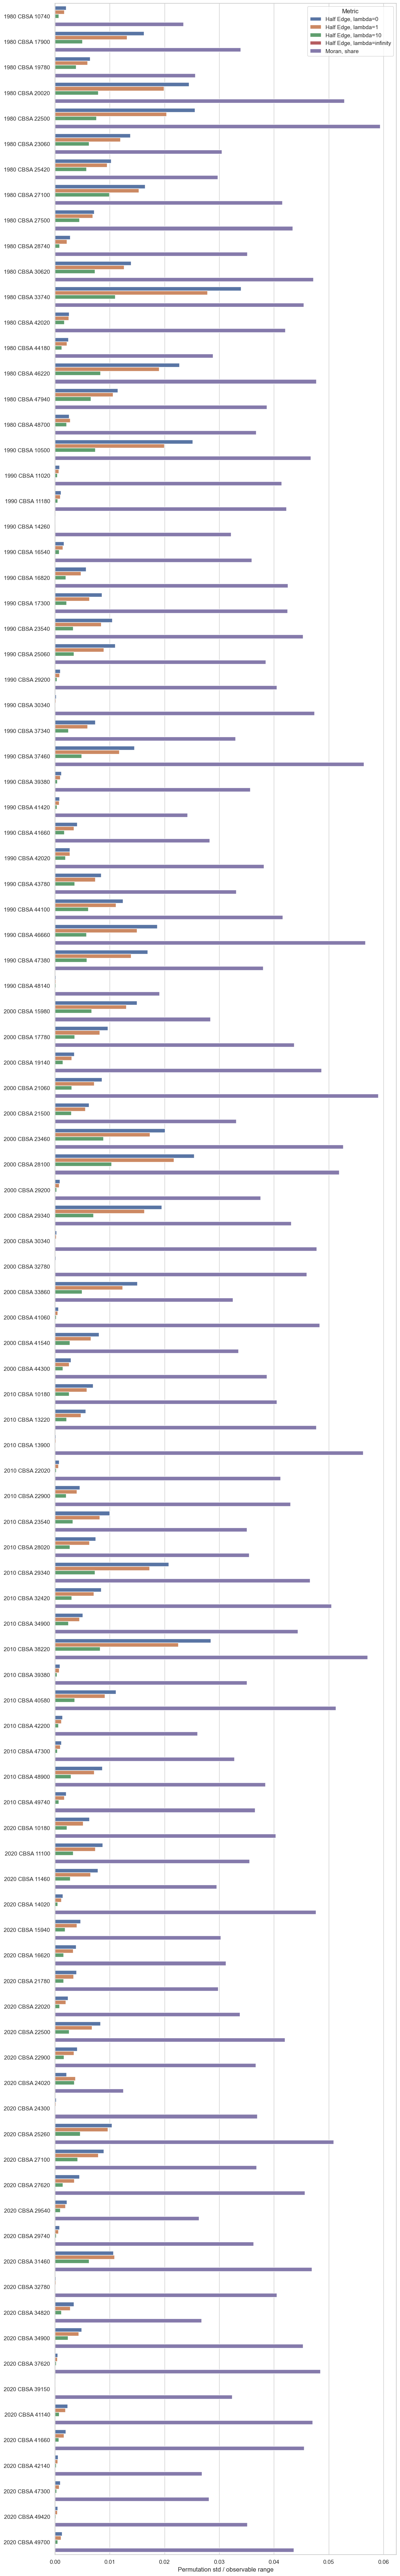

In [58]:
missing_result_columns = [column for column in metric_columns if column not in results.columns]
if missing_result_columns:
    raise ValueError(
        "Rerun the permutation cell after updating metric_values; missing columns: "
        + ", ".join(missing_result_columns)
    )

permuted_results = results[~results["is_observed"]]
observed_results = results[results["is_observed"]].set_index("area_key")

observable_ranges = {
    "dissimilarity": 1.0,
    "half_edge_lam_0_angle_1": 1.0,
    "half_edge_lam_1_angle_1": 1.0,
    "half_edge_lam_10_angle_1": 1.0,
    "half_edge_lam_lim_angle_1": 1.0,
    "moran_share": 2.0,
}

spread_rows = []
for metric in metric_columns:
    metric_stats = (
        permuted_results.groupby("area_key")[metric]
        .agg(
            permutation_mean="mean",
            permutation_sd="std",
            permutation_min="min",
            permutation_max="max",
        )
        .reset_index()
    )
    observed_values = observed_results[metric]
    percentile_frame = permuted_results[["area_key", metric]].copy()
    percentile_frame["observed_value"] = percentile_frame["area_key"].map(observed_values)
    percentile_frame["is_below_observed"] = percentile_frame[metric] <= percentile_frame["observed_value"]
    observed_percentiles = percentile_frame.groupby("area_key")["is_below_observed"].mean()

    metric_stats["metric"] = metric
    metric_stats["metric_label"] = metric_labels[metric]
    metric_stats["observed_value"] = metric_stats["area_key"].map(observed_values)
    metric_stats["observed_percentile_vs_permutations"] = metric_stats["area_key"].map(
        observed_percentiles
    )
    metric_stats["normalized_min"] = np.where(
        metric_stats["permutation_sd"] > 1e-12,
        (metric_stats["permutation_min"] - metric_stats["observed_value"])
        / metric_stats["permutation_sd"],
        0.0,
    )
    metric_stats["normalized_max"] = np.where(
        metric_stats["permutation_sd"] > 1e-12,
        (metric_stats["permutation_max"] - metric_stats["observed_value"])
        / metric_stats["permutation_sd"],
        0.0,
    )
    metric_stats["observable_range"] = observable_ranges[metric]
    metric_stats["std_over_observable_range"] = (
        metric_stats["permutation_sd"] / metric_stats["observable_range"]
    )
    metric_stats["range_over_observable_range"] = (
        (metric_stats["permutation_max"] - metric_stats["permutation_min"])
        / metric_stats["observable_range"]
    )
    spread_rows.append(metric_stats)

normalized_spread = pd.concat(spread_rows, ignore_index=True)
spread_table = normalized_spread.copy()

normalized_spread.sort_values(["area_key", "metric"])[
    [
        "area_key",
        "metric_label",
        "permutation_sd",
        "observable_range",
        "std_over_observable_range",
        "range_over_observable_range"]]

area_order = sample_rows["area_key"].tolist()

plt.figure(figsize=(11, max(4, 0.7 * len(area_order))))
sns.barplot(
    data=normalized_spread,
    x="std_over_observable_range",
    y="area_key",
    hue="metric_label",
    order=area_order,
)
plt.xlabel("Permutation std / observable range")
plt.ylabel("")
plt.legend(title="Metric", loc="best")
plt.tight_layout()

## Pick contrast cases

Compare Half Edge and Moran by their normalized permutation spreads. The similarity score below is `min(half_edge_spread, moran_spread) / max(half_edge_spread, moran_spread)`, so values near `1` mean the two metrics swing by similar amounts and values near `0` mean one moves much less than the other.

In [64]:
normalized_spread.head(2)

,area_key,permutation_mean,permutation_sd,permutation_min,permutation_max,metric,metric_label,observed_value,observed_percentile_vs_permutations,normalized_min,normalized_max,observable_range,std_over_observable_range,range_over_observable_range
0,1980 CBSA 10740,0.499443,0.002014,0.494828,0.508810,half_edge_lam_0_angle_1,"Half Edge, lambda=0",0.511453,1.0,-8.254180,-1.312276,1.0,0.002014,0.013982
1,1980 CBSA 17900,0.498004,0.016242,0.446460,0.557601,half_edge_lam_0_angle_1,"Half Edge, lambda=0",0.604582,1.0,-9.735547,-2.892580,1.0,0.016242,0.111141


In [59]:
spread_wide = (
    normalized_spread.pivot_table(
        index="area_key",
        columns="metric",
        values="std_over_observable_range",
    )
    .reset_index()
    .rename(
        columns={
            # "half_edge_lam_1_angle_1": "half_edge_spread",
            "half_edge_lam_0_angle_1": "half_edge_spread",
            "moran_share": "moran_spread",
            "dissimilarity": "dissimilarity_spread",
        }
    )
)

area_metadata = sample_rows[
    [
        "area_key",
        "year",
        "cbsa",
        "filename",
        "total_nodes",
        "total_edges",
        "total_population",
        "total_black",
        "total_white",
        "total_x",
        "total_y",
        "dissimilarity",
        "half_edge_lam_0_angle_1",
        "moran",
    ]
].copy()
area_metadata["edge_density"] = (
    2 * area_metadata["total_edges"]
    / (area_metadata["total_nodes"] * (area_metadata["total_nodes"] - 1))
)
area_metadata["black_to_white_ratio"] = area_metadata["total_black"] / area_metadata["total_white"]

spread_wide = spread_wide.merge(area_metadata, on="area_key")
spread_wide["he_moran_abs_gap"] = (spread_wide["half_edge_spread"] - spread_wide["moran_spread"]).abs()
spread_wide["he_to_moran_spread_ratio"] = spread_wide["half_edge_spread"] / spread_wide["moran_spread"]
spread_wide["spread_similarity"] = np.where(
    spread_wide[["half_edge_spread", "moran_spread"]].max(axis=1) > 0,
    spread_wide[["half_edge_spread", "moran_spread"]].min(axis=1)
    / spread_wide[["half_edge_spread", "moran_spread"]].max(axis=1),
    np.nan,
)

ranking_columns = [
    "area_key",
    "year",
    "cbsa",
    "total_nodes",
    "total_edges",
    "edge_density",
    "total_x",
    "dissimilarity",
    "half_edge_lam_1_angle_1",
    "moran",
    "half_edge_spread",
    "moran_spread",
    "he_moran_abs_gap",
    "he_to_moran_spread_ratio",
    "spread_similarity",
]

spread_wide.sort_values("spread_similarity", ascending=False)[ranking_columns].head(10)

,area_key,year,cbsa,total_nodes,total_edges,edge_density,total_x,dissimilarity,half_edge_lam_1_angle_1,moran,half_edge_spread,moran_spread,he_moran_abs_gap,he_to_moran_spread_ratio,spread_similarity
11,1980 CBSA 33740,1980,33740,37,93,0.139640,0.289462,0.689967,0.027823,0.418978,0.034005,0.045472,0.011467,0.747821,0.747821
17,1990 CBSA 10500,1990,10500,45,114,0.115152,0.445673,0.569720,0.019935,0.534349,0.025145,0.046723,0.021578,0.538178,0.538178
39,2000 CBSA 15980,2000,15980,117,306,0.045093,0.063554,0.693569,0.013006,0.618580,0.014973,0.028404,0.013431,0.527151,0.527151
64,2010 CBSA 38220,2010,38220,30,67,0.154023,0.476261,0.616232,0.022553,0.565219,0.028457,0.057136,0.028679,0.498061,0.498061
45,2000 CBSA 28100,2000,28100,26,61,0.187692,0.153535,0.711990,0.021704,0.322740,0.025443,0.051948,0.026506,0.489766,0.489766
1,1980 CBSA 17900,1980,17900,92,236,0.056378,0.284729,0.573944,0.013134,0.490186,0.016242,0.033950,0.017709,0.478395,0.478395
14,1980 CBSA 46220,1980,46220,26,66,0.203077,0.268553,0.490996,0.019011,0.341473,0.022732,0.047753,0.025022,0.476021,0.476021
50,2000 CBSA 33860,2000,33860,82,209,0.062933,0.400891,0.558129,0.012315,0.506454,0.015056,0.032470,0.017414,0.463694,0.463694
3,1980 CBSA 20020,1980,20020,33,73,0.138258,0.220191,0.561345,0.019913,0.256020,0.024510,0.052893,0.028383,0.463391,0.463391
47,2000 CBSA 29340,2000,29340,43,107,0.118494,0.228121,0.620769,0.016287,0.558940,0.019505,0.043184,0.023679,0.451669,0.451669


In [60]:
closest_swing_case = spread_wide.nlargest(5, "spread_similarity").assign(
    selection="closest Half Edge/Moran swing"
)
lowest_swing_case = spread_wide.nsmallest(5, "spread_similarity").assign(
    selection="lowest Half Edge/Moran swing similarity"
)

selected_cases = pd.concat([closest_swing_case, lowest_swing_case], ignore_index=True)
selected_area_keys = selected_cases["area_key"].tolist()

selected_cases[
    [
        "selection",
        "area_key",
        "year",
        "cbsa",
        "total_nodes",
        "total_edges",
        "edge_density",
        "total_population",
        "total_black",
        "total_white",
        "total_x",
        "dissimilarity",
        "half_edge_lam_1_angle_1",
        "moran",
        "half_edge_spread",
        "moran_spread",
        "he_moran_abs_gap",
        "he_to_moran_spread_ratio",
        "spread_similarity",
        "filename",
    ]
]

,selection,area_key,year,cbsa,total_nodes,total_edges,edge_density,total_population,total_black,total_white,total_x,dissimilarity,half_edge_lam_1_angle_1,moran,half_edge_spread,moran_spread,he_moran_abs_gap,he_to_moran_spread_ratio,spread_similarity,filename
0,closest Half Edge/Moran swing,1980 CBSA 33740,1980,33740,37,93,0.139640,139241,40305,97060,0.289462,0.689967,0.027823,0.418978,0.034005,0.045472,0.011467,0.747821,0.747821,study_areas/1980/tracts_in_cbsa_33740_1980_mar...
1,closest Half Edge/Moran swing,1990 CBSA 10500,1990,10500,45,114,0.115152,142959,63713,77201,0.445673,0.569720,0.019935,0.534349,0.025145,0.046723,0.021578,0.538178,0.538178,study_areas/1990/tracts_in_cbsa_10500_1990_mar...
2,closest Half Edge/Moran swing,2000 CBSA 15980,2000,15980,117,306,0.045093,440888,28020,361439,0.063554,0.693569,0.013006,0.618580,0.014973,0.028404,0.013431,0.527151,0.527151,study_areas/2000/tracts_in_cbsa_15980_2000_mar...
3,closest Half Edge/Moran swing,2010 CBSA 38220,2010,38220,30,67,0.154023,100258,47749,48740,0.476261,0.616232,0.022553,0.565219,0.028457,0.057136,0.028679,0.498061,0.498061,study_areas/2010/tracts_in_cbsa_38220_2010_mar...
4,closest Half Edge/Moran swing,2000 CBSA 28100,2000,28100,26,61,0.187692,103833,15942,80829,0.153535,0.711990,0.021704,0.322740,0.025443,0.051948,0.026506,0.489766,0.489766,study_areas/2000/tracts_in_cbsa_28100_2000_mar...
5,lowest Half Edge/Moran swing similarity,2010 CBSA 13900,2010,13900,25,63,0.210000,110625,591,102373,0.005342,0.274696,0.000109,0.203001,0.000132,0.056285,0.056153,0.002342,0.002342,study_areas/2010/tracts_in_cbsa_13900_2010_mar...
6,lowest Half Edge/Moran swing similarity,2000 CBSA 32780,2000,32780,36,97,0.153968,181269,674,160795,0.003718,0.294974,0.000095,0.241410,0.000113,0.046001,0.045889,0.002446,0.002446,study_areas/2000/tracts_in_cbsa_32780_2000_mar...
7,lowest Half Edge/Moran swing similarity,2020 CBSA 39150,2020,39150,72,193,0.075509,236209,1415,183296,0.005990,0.208252,0.000065,0.145202,0.000079,0.032369,0.032290,0.002452,0.002452,study_areas/2020/tracts_in_cbsa_39150_2020_mar...
8,lowest Half Edge/Moran swing similarity,1990 CBSA 14260,1990,14260,72,187,0.073161,319596,1124,292662,0.003517,0.315791,0.000085,0.289924,0.000102,0.032153,0.032051,0.003179,0.003179,study_areas/1990/tracts_in_cbsa_14260_1990_mar...
9,lowest Half Edge/Moran swing similarity,2020 CBSA 32780,2020,32780,52,139,0.104827,223259,1574,170232,0.007050,0.242164,0.000110,0.415323,0.000131,0.040528,0.040396,0.003238,0.003238,study_areas/2020/tracts_in_cbsa_32780_2020_mar...


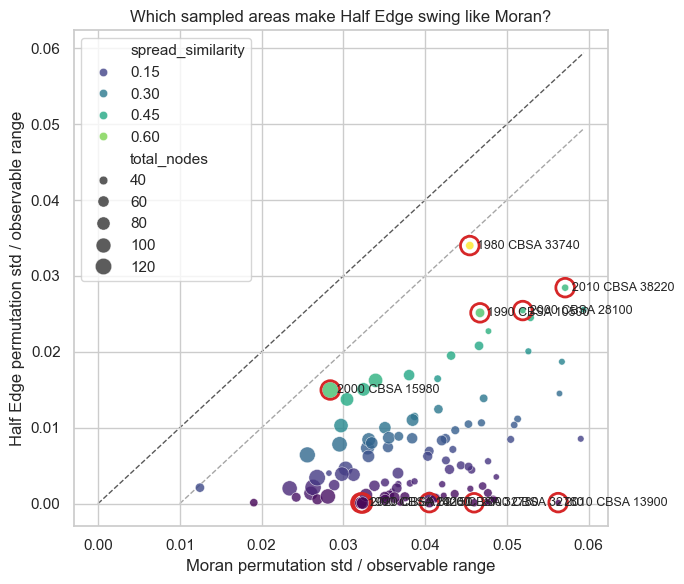

In [61]:
plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=spread_wide,
    x="moran_spread",
    y="half_edge_spread",
    hue="spread_similarity",
    size="total_nodes",
    sizes=(20, 140),
    palette="viridis",
    alpha=0.8,
)

max_spread = spread_wide[["moran_spread", "half_edge_spread"]].max().max()
plt.plot([0, max_spread], [0, max_spread], color="0.35", linestyle="--", linewidth=1, zorder=0)
plt.plot([0.01, max_spread], [0, max_spread - 0.01], color="0.65", linestyle="--", linewidth=1, zorder=0)

for case in selected_cases.itertuples(index=False):
    plt.scatter(
        case.moran_spread,
        case.half_edge_spread,
        s=180,
        facecolors="none",
        edgecolors="#D62728",
        linewidths=2,
    )
    plt.text(
        case.moran_spread,
        case.half_edge_spread,
        "  " + case.area_key,
        va="center",
        fontsize=9,
    )

plt.xlabel("Moran permutation std / observable range")
plt.ylabel("Half Edge permutation std / observable range")
plt.title("Which sampled areas make Half Edge swing like Moran?")
plt.tight_layout()

## Selected case distributions

For the selected areas, this compares permutation swings around the observed placement after dividing by each metric's observable range. This keeps the two selected cases on the same visual scale.

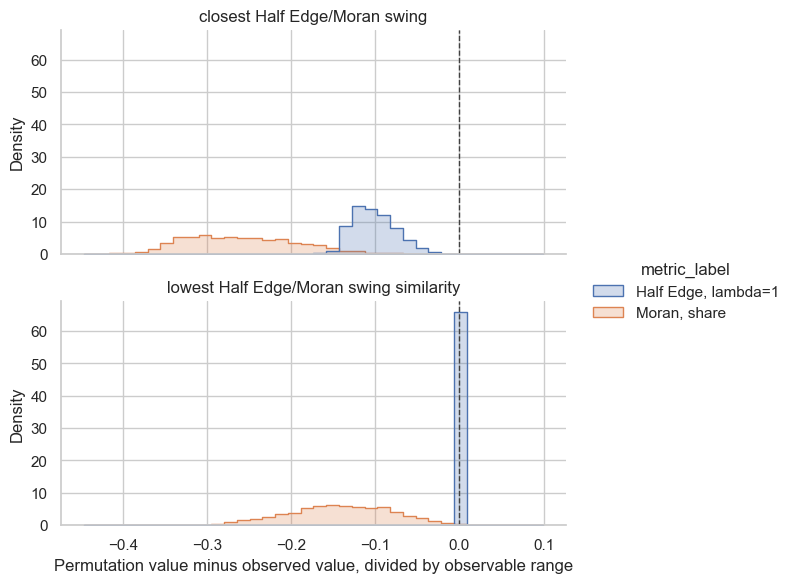

In [62]:
selected_plot_rows = []
observed_selected = results[results["is_observed"]].set_index("area_key")
selected_permutations = results[
    results["area_key"].isin(selected_area_keys) & (~results["is_observed"])
]

for metric in ["half_edge_lam_1_angle_1", "moran_share"]:
    metric_frame = selected_permutations[
        ["area_key", "year", "cbsa", "filename", "placement", "permutation", metric]
    ].rename(columns={metric: "value"})
    metric_frame["metric"] = metric
    metric_frame["metric_label"] = metric_labels[metric]
    metric_frame["observed_value"] = metric_frame["area_key"].map(observed_selected[metric])
    metric_frame["observable_range"] = observable_ranges[metric]
    metric_frame["range_scaled_delta_from_observed"] = (
        (metric_frame["value"] - metric_frame["observed_value"])
        / metric_frame["observable_range"]
    )
    selected_plot_rows.append(metric_frame)

selected_long = pd.concat(selected_plot_rows, ignore_index=True)
selected_long = selected_long.merge(
    selected_cases[["area_key", "selection"]],
    on="area_key",
    how="left",
)

g = sns.displot(
    data=selected_long,
    x="range_scaled_delta_from_observed",
    hue="metric_label",
    row="selection",
    kind="hist",
    bins=36,
    element="step",
    stat="density",
    common_norm=False,
    height=3.0,
    aspect=2.0,
)
for ax in g.axes.flat:
    ax.axvline(0, color="0.25", linestyle="--", linewidth=1)
    ax.set_xlabel("Permutation value minus observed value, divided by observable range")
g.set_titles("{row_name}")

## Quick profile: high-similarity vs low-similarity tails

This compares the ten areas where Half Edge's spread is closest to Moran's with the ten areas where it is least similar. It is descriptive, but it gives clues about graph size, graph density, and composition mix.

In [63]:
tail_count = min(10, len(spread_wide) // 2)
high_similarity = spread_wide.nlargest(tail_count, "spread_similarity").assign(
    similarity_group="highest similarity"
)
low_similarity = spread_wide.nsmallest(tail_count, "spread_similarity").assign(
    similarity_group="lowest similarity"
)
tail_cases = pd.concat([high_similarity, low_similarity], ignore_index=True)

profile_columns = [
    "total_nodes",
    "total_edges",
    "edge_density",
    "total_population",
    "total_x",
    "black_to_white_ratio",
    "dissimilarity",
    "half_edge_lam_1_angle_1",
    "moran",
    "half_edge_spread",
    "moran_spread",
    "he_to_moran_spread_ratio",
    "spread_similarity",
]

tail_cases.groupby("similarity_group")[profile_columns].agg(["mean", "median"]).T

similarity_group                 highest similarity  lowest similarity
total_nodes              mean             53.100000          41.300000
                         median           40.000000          34.500000
total_edges              mean            133.200000         106.800000
                         median          100.000000          87.500000
edge_density             mean              0.122074           0.145329
                         median            0.128376           0.155583
total_population         mean         212909.100000      166759.600000
                         median       141100.000000      149048.000000
total_x                  mean              0.283097           0.005539
                         median            0.276641           0.005666
black_to_white_ratio     mean              0.458395           0.006372
                         median            0.392782           0.006120
dissimilarity            mean              0.608666           0.301474
                         median            0.595088           0.292798
half_edge_lam_1_angle_1  mean              0.018568           0.000152
                         median            0.019462           0.000126
moran                    mean              0.461294           0.261963
                         median            0.498320           0.271207
half_edge_spread         mean              0.022607           0.000178
                         median            0.023621           0.000132
moran_spread             mean              0.043993           0.040700
                         median            0.046097           0.043265
he_to_moran_spread_ratio mean              0.513415           0.004418
                         median            0.484080           0.003444
spread_similarity        mean              0.513415           0.004418
                         median            0.484080           0.003444

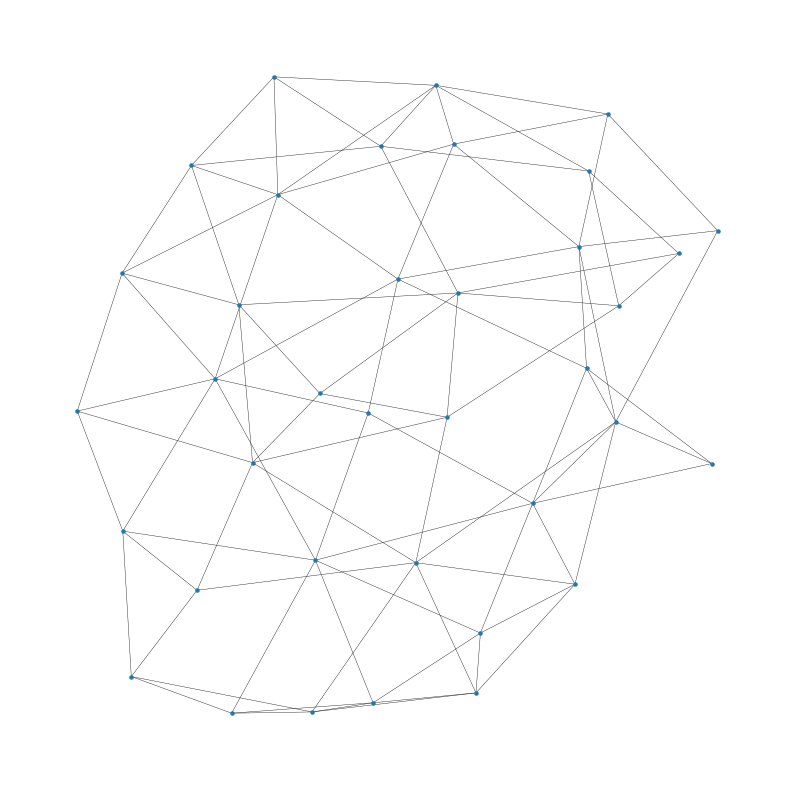

In [123]:
# plot a graph from json graph file for the two selected cases:
from matplotlib.pylab import partition
import networkx as nx
import matplotlib.pyplot as plt


file_path = "/Users/maria/Documents/capy-bara/study_areas/1980/tracts_in_cbsa_33740_1980_march_2020_vintage_connected.json"

graph_small_swing = gerrychain.Graph.from_json(file_path)
#plot:
fig, ax = plt.subplots(figsize=(10, 10))

nx.draw(
    graph_small_swing,
    ax=ax,
    node_size=5,
    width=0.3,
    with_labels=False
)

plt.show()

In [ ]:
# calculate edges over nodes for both selected cases:
edges_1980 = len(graph_small_swing.edges())
nodes_1980 = len(graph_small_swing.nodes())

edges_1980/nodes_1980

2.5135135135135136

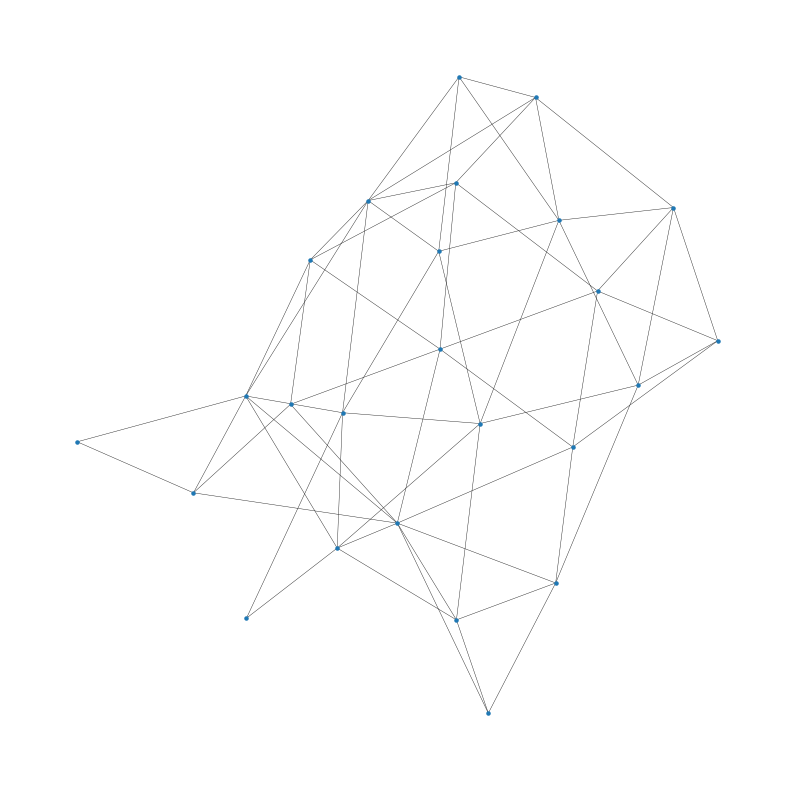

In [ ]:
# plot a graph from json graph file for the two selected cases:
from matplotlib.pylab import partition
import networkx as nx
import matplotlib.pyplot as plt


file_path = "/Users/maria/Documents/capy-bara/study_areas/2010/tracts_in_cbsa_13900_2010_march_2020_vintage_connected.json"

graph_large_swing = gerrychain.Graph.from_json(file_path)
#plot:
fig, ax = plt.subplots(figsize=(10, 10))

nx.draw(
    graph_large_swing,
    ax=ax,
    node_size=5,
    width=0.3,
    with_labels=False
)

plt.show()

In [ ]:
# calculate edges over nodes for both selected cases:
edges_2010 = len(graph_large_swing.edges())
nodes_2010 = len(graph_large_swing.nodes())

edges_2010/nodes_2010

2.52

## Plot the suspects

### The closest swing case:

In [60]:
# gdf[["BLACK", "WHITE", "TOTPOP", "BLACK_share", "WHITE_share"]].head(2)
gdf[share_cols].head(5)

,WHITE_share,BLACK_share,POC_share
0,0.704878,0.275610,0.295122
1,0.967053,0.021346,0.032947
2,0.063654,0.927308,0.936346
3,0.984504,0.007367,0.015496
4,0.796856,0.180975,0.203144


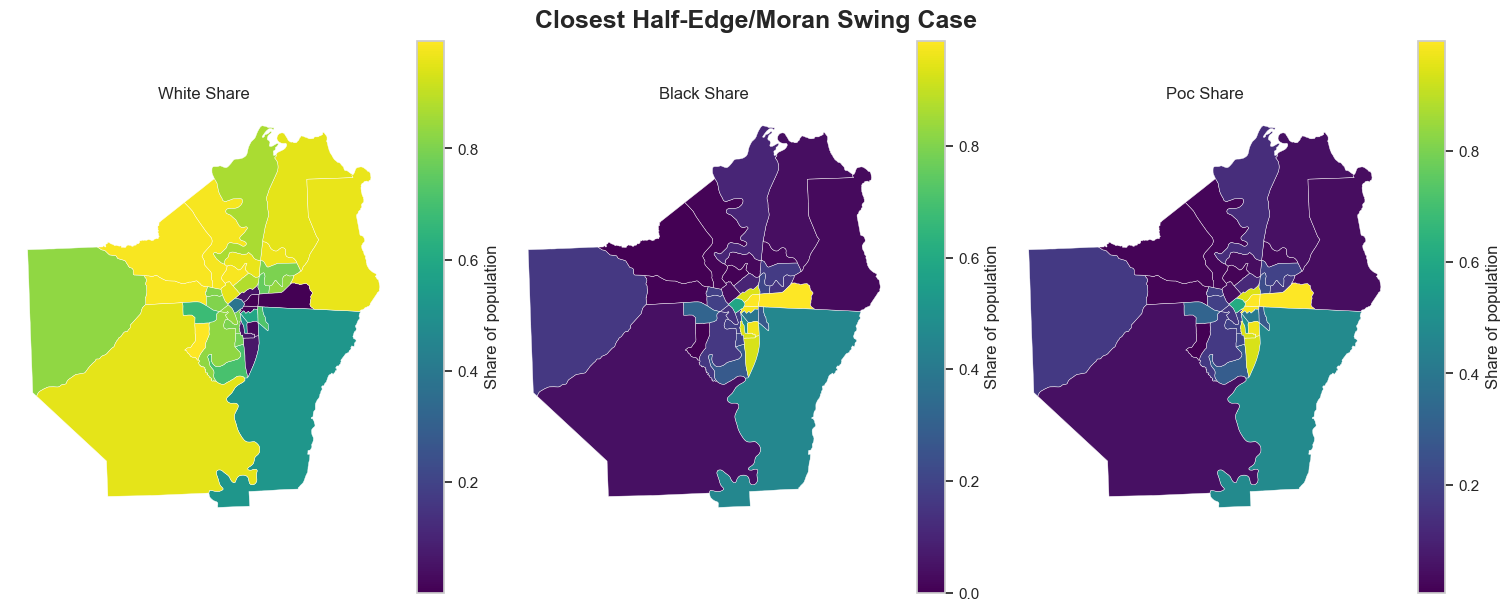

In [168]:
# plot a heatmap of this CBSA's shapefile using geopandas and matplotlib:
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = "/Users/maria/Documents/capy-bara/study_areas/1980/tracts_in_cbsa_33740_1980_march_2020_vintage.shp"
gdf = gpd.read_file(file_path)

import matplotlib.pyplot as plt

# population_cols = ["WHITE", "BLACK", "POC", "TOTPOP"]
for col in ["WHITE", "BLACK", "POC"]:
    gdf[f"{col}_share"] = gdf[col] / gdf["TOTPOP"]
share_cols = [f"{col}_share" for col in ["WHITE", "BLACK", "POC"]]

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(share_cols),
    figsize=(5 * len(share_cols), 6),
    constrained_layout=True,
)

fig.suptitle(
    t="Closest Half-Edge/Moran Swing Case",
    fontsize=18,
    fontweight="bold"
)

for ax, col in zip(axes, share_cols):
    gdf.plot(
        column=col,
        ax=ax,
        cmap="viridis",
        legend=True,
        legend_kwds={
            "label": "Share of population",
        },
        edgecolor="white",
        linewidth=0.3,
        missing_kwds={
            "color": "lightgrey",
            "label": "Missing"
        }
    )

    ax.set_title(col.replace("_", " ").title())
    ax.set_axis_off()

plt.show()


In [63]:
# deviation from mean of the share of BLACK and WHITE population in the closest swing case:
deviation_black = gdf["BLACK_share"].std()
deviation_white = gdf["WHITE_share"].std()

print(f"Deviation for BLACK_share: {deviation_black}")
print(f"Deviation for WHITE_share: {deviation_white}")

Deviation for BLACK_share: 0.3453542331901004
Deviation for WHITE_share: 0.34464418460875657


### The furthest swing case

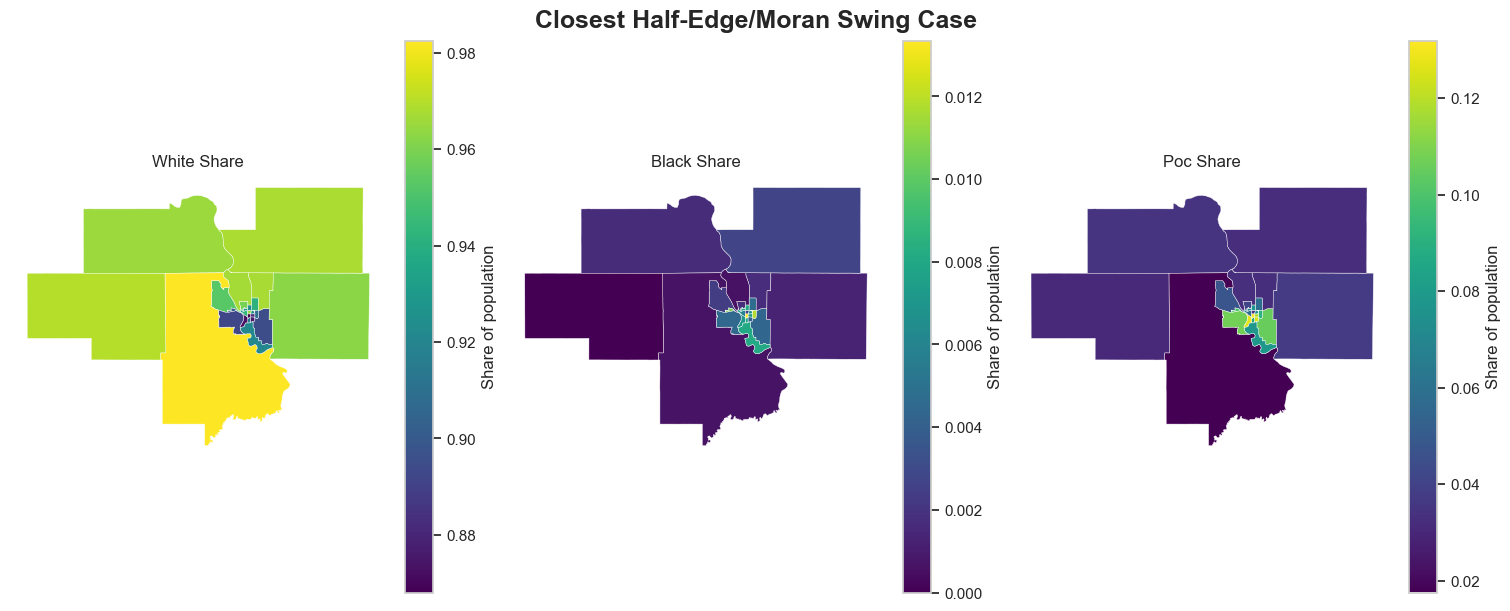

In [169]:
# plot a heatmap of this CBSA's shapefile using geopandas and matplotlib:
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = "/Users/maria/Documents/capy-bara/study_areas/2010/tracts_in_cbsa_13900_2010_march_2020_vintage.shp"
gdf = gpd.read_file(file_path)

import matplotlib.pyplot as plt

# population_cols = ["WHITE", "BLACK", "POC", "TOTPOP"]
for col in ["WHITE", "BLACK", "POC"]:
    gdf[f"{col}_share"] = gdf[col] / gdf["TOTPOP"]
share_cols = [f"{col}_share" for col in ["WHITE", "BLACK", "POC"]]

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(share_cols),
    figsize=(5 * len(share_cols), 6),
    constrained_layout=True,
)

fig.suptitle(
    t="Closest Half-Edge/Moran Swing Case",
    fontsize=18,
    fontweight="bold"
)

for ax, col in zip(axes, share_cols):
    gdf.plot(
        column=col,
        ax=ax,
        cmap="viridis",
        legend=True,
        legend_kwds={
            "label": "Share of population",
        },
        edgecolor="white",
        linewidth=0.3,
        missing_kwds={
            "color": "lightgrey",
            "label": "Missing"
        }
    )

    ax.set_title(col.replace("_", " ").title())
    ax.set_axis_off()

plt.show()


In [65]:
# deviation from mean of the share of BLACK and WHITE population in the closest swing case:
deviation_black = gdf["BLACK_share"].std()
deviation_white = gdf["WHITE_share"].std()

print(f"Deviation for BLACK_share: {deviation_black}")
print(f"Deviation for WHITE_share: {deviation_white}")

Deviation for BLACK_share: 0.003675481375445764
Deviation for WHITE_share: 0.03559917272691281


## Top and bottom ten case views

The next cells repeat the graph and map views for the ten areas where Half Edge's permutation spread is closest to Moran's, and the ten areas where it is least similar. The tract maps show White share, Black share, and tract-level `black_to_white_ratio`.

In [65]:
import geopandas as gpd
import networkx as nx

if "project_root" not in globals():
    for candidate_root in [Path.cwd(), *Path.cwd().parents]:
        if (candidate_root / "pipeline" / "calculate_metrics.py").exists():
            project_root = candidate_root
            break
    else:
        raise FileNotFoundError("Could not find the project root")

tail_count = min(10, len(spread_wide) // 2)
top_10_cases = spread_wide.nlargest(tail_count, "spread_similarity").assign(
    similarity_group="highest similarity"
)
bottom_10_cases = spread_wide.nsmallest(tail_count, "spread_similarity").assign(
    similarity_group="lowest similarity"
)
top_bottom_cases = pd.concat([top_10_cases, bottom_10_cases], ignore_index=True)

top_bottom_cases["json_path"] = top_bottom_cases["filename"].apply(lambda filename: project_root / filename)
top_bottom_cases["shapefile_path"] = top_bottom_cases["filename"].apply(
    lambda filename: project_root / filename.replace("_connected.json", ".shp")
)

top_bottom_cases[
    [
        "similarity_group",
        "area_key",
        "total_nodes",
        "total_edges",
        "edge_density",
        "total_x",
        "black_to_white_ratio",
        "half_edge_spread",
        "moran_spread",
        "he_to_moran_spread_ratio",
        "spread_similarity",
        "shapefile_path",
    ]
]

,similarity_group,area_key,total_nodes,total_edges,edge_density,total_x,black_to_white_ratio,half_edge_spread,moran_spread,he_to_moran_spread_ratio,spread_similarity,shapefile_path
0,highest similarity,1980 CBSA 33740,37,93,0.139640,0.289462,0.415259,0.034005,0.045472,0.747821,0.747821,/Users/maria/Documents/capy-bara/study_areas/1...
1,highest similarity,1990 CBSA 10500,45,114,0.115152,0.445673,0.825287,0.025145,0.046723,0.538178,0.538178,/Users/maria/Documents/capy-bara/study_areas/1...
2,highest similarity,2000 CBSA 15980,117,306,0.045093,0.063554,0.077523,0.014973,0.028404,0.527151,0.527151,/Users/maria/Documents/capy-bara/study_areas/2...
3,highest similarity,2010 CBSA 38220,30,67,0.154023,0.476261,0.979668,0.028457,0.057136,0.498061,0.498061,/Users/maria/Documents/capy-bara/study_areas/2...
4,highest similarity,2000 CBSA 28100,26,61,0.187692,0.153535,0.197231,0.025443,0.051948,0.489766,0.489766,/Users/maria/Documents/capy-bara/study_areas/2...
5,highest similarity,1980 CBSA 17900,92,236,0.056378,0.284729,0.411431,0.016242,0.033950,0.478395,0.478395,/Users/maria/Documents/capy-bara/study_areas/1...
6,highest similarity,1980 CBSA 46220,26,66,0.203077,0.268553,0.374133,0.022732,0.047753,0.476021,0.476021,/Users/maria/Documents/capy-bara/study_areas/1...
7,highest similarity,2000 CBSA 33860,82,209,0.062933,0.400891,0.706896,0.015056,0.032470,0.463694,0.463694,/Users/maria/Documents/capy-bara/study_areas/2...
8,highest similarity,1980 CBSA 20020,33,73,0.138258,0.220191,0.287641,0.024510,0.052893,0.463391,0.463391,/Users/maria/Documents/capy-bara/study_areas/1...
9,highest similarity,2000 CBSA 29340,43,107,0.118494,0.228121,0.308877,0.019505,0.043184,0.451669,0.451669,/Users/maria/Documents/capy-bara/study_areas/2...


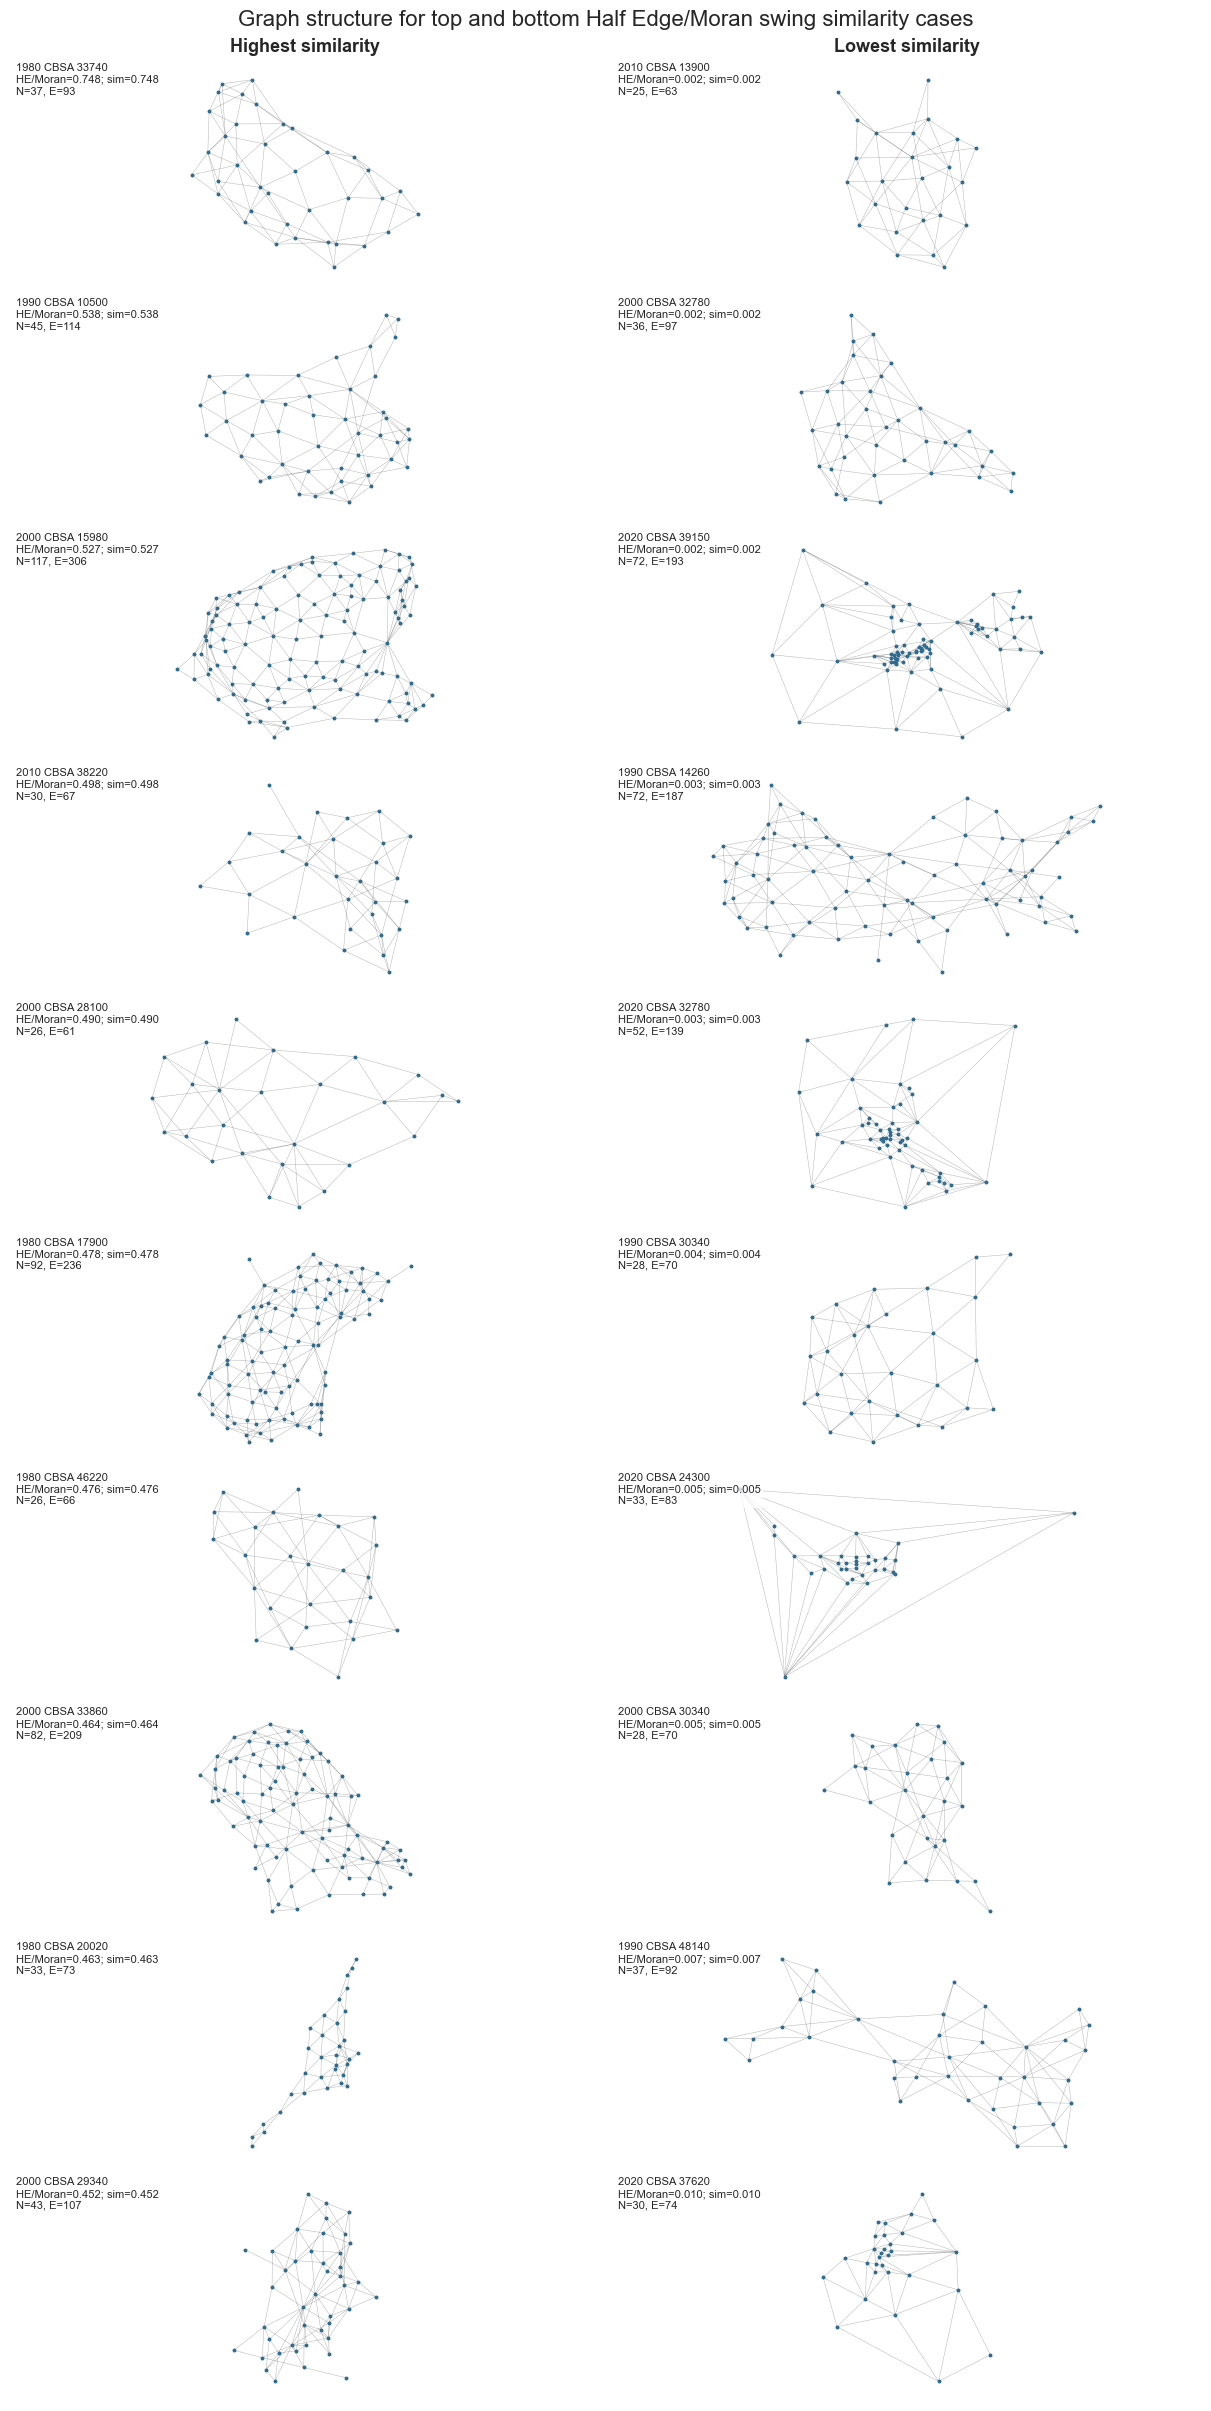

In [66]:
case_groups = [
    ("Highest similarity", top_10_cases),
    ("Lowest similarity", bottom_10_cases),
]
max_rows = max(len(cases) for _, cases in case_groups)
fig, axes = plt.subplots(
    nrows=max_rows,
    ncols=len(case_groups),
    figsize=(12, max(4, 2.4 * max_rows)),
    constrained_layout=True,
    squeeze=False,
)

for col_index, (group_title, cases) in enumerate(case_groups):
    axes[0, col_index].set_title(group_title, fontsize=13, fontweight="bold")
    for row_index, case in enumerate(cases.itertuples(index=False)):
        ax = axes[row_index, col_index]
        graph = gerrychain.Graph.from_json(project_root / case.filename)
        positions = {}
        for node, data in graph.nodes(data=True):
            try:
                positions[node] = (float(data["INTPTLON"]), float(data["INTPTLAT"]))
            except (KeyError, TypeError, ValueError):
                positions = {}
                break
        if len(positions) != len(graph.nodes):
            positions = nx.spring_layout(graph, seed=RANDOM_SEED)

        nx.draw_networkx_edges(graph, positions, ax=ax, width=0.35, alpha=0.45, edge_color="0.35")
        nx.draw_networkx_nodes(graph, positions, ax=ax, node_size=8, node_color="#2F6B8F", linewidths=0)
        ax.set_aspect("equal", adjustable="datalim")
        ax.set_axis_off()
        ax.text(
            0.01,
            0.99,
            f"{case.area_key}\nHE/Moran={case.he_to_moran_spread_ratio:.3f}; sim={case.spread_similarity:.3f}\nN={case.total_nodes}, E={case.total_edges}",
            transform=ax.transAxes,
            va="top",
            ha="left",
            fontsize=8,
            bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.75, "pad": 2},
        )

    for row_index in range(len(cases), max_rows):
        axes[row_index, col_index].set_axis_off()

fig.suptitle("Graph structure for top and bottom Half Edge/Moran swing similarity cases", fontsize=16)
plt.show()

In [67]:
case_geographies = []
for case in top_bottom_cases.itertuples(index=False):
    gdf = gpd.read_file(case.shapefile_path)
    gdf["WHITE_share"] = np.where(gdf[TOT_COL] > 0, gdf["WHITE"] / gdf[TOT_COL], np.nan)
    gdf["BLACK_share"] = np.where(gdf[TOT_COL] > 0, gdf["BLACK"] / gdf[TOT_COL], np.nan)
    gdf["black_to_white_ratio"] = np.where(gdf["WHITE"] > 0, gdf["BLACK"] / gdf["WHITE"], np.nan)
    case_geographies.append({"case": case, "gdf": gdf})

all_ratio_values = pd.concat(
    [entry["gdf"]["black_to_white_ratio"].replace([np.inf, -np.inf], np.nan).dropna() for entry in case_geographies],
    ignore_index=True,
)
ratio_color_max = all_ratio_values.quantile(0.95) if len(all_ratio_values) else 1.0

map_columns = ["WHITE_share", "BLACK_share", "black_to_white_ratio"]
map_titles = {
    "WHITE_share": "White Share",
    "BLACK_share": "Black Share",
    "black_to_white_ratio": "Black / White Ratio",
}
map_color_settings = {
    "WHITE_share": {"cmap": "Blues", "vmin": 0, "vmax": 1},
    "BLACK_share": {"cmap": "Purples", "vmin": 0, "vmax": 1},
    "black_to_white_ratio": {"cmap": "magma", "vmin": 0, "vmax": ratio_color_max},
}

top_bottom_cases[["similarity_group", "area_key", "shapefile_path"]]

,similarity_group,area_key,shapefile_path
0,highest similarity,1980 CBSA 33740,/Users/maria/Documents/capy-bara/study_areas/1...
1,highest similarity,1990 CBSA 10500,/Users/maria/Documents/capy-bara/study_areas/1...
2,highest similarity,2000 CBSA 15980,/Users/maria/Documents/capy-bara/study_areas/2...
3,highest similarity,2010 CBSA 38220,/Users/maria/Documents/capy-bara/study_areas/2...
4,highest similarity,2000 CBSA 28100,/Users/maria/Documents/capy-bara/study_areas/2...
5,highest similarity,1980 CBSA 17900,/Users/maria/Documents/capy-bara/study_areas/1...
6,highest similarity,1980 CBSA 46220,/Users/maria/Documents/capy-bara/study_areas/1...
7,highest similarity,2000 CBSA 33860,/Users/maria/Documents/capy-bara/study_areas/2...
8,highest similarity,1980 CBSA 20020,/Users/maria/Documents/capy-bara/study_areas/1...
9,highest similarity,2000 CBSA 29340,/Users/maria/Documents/capy-bara/study_areas/2...


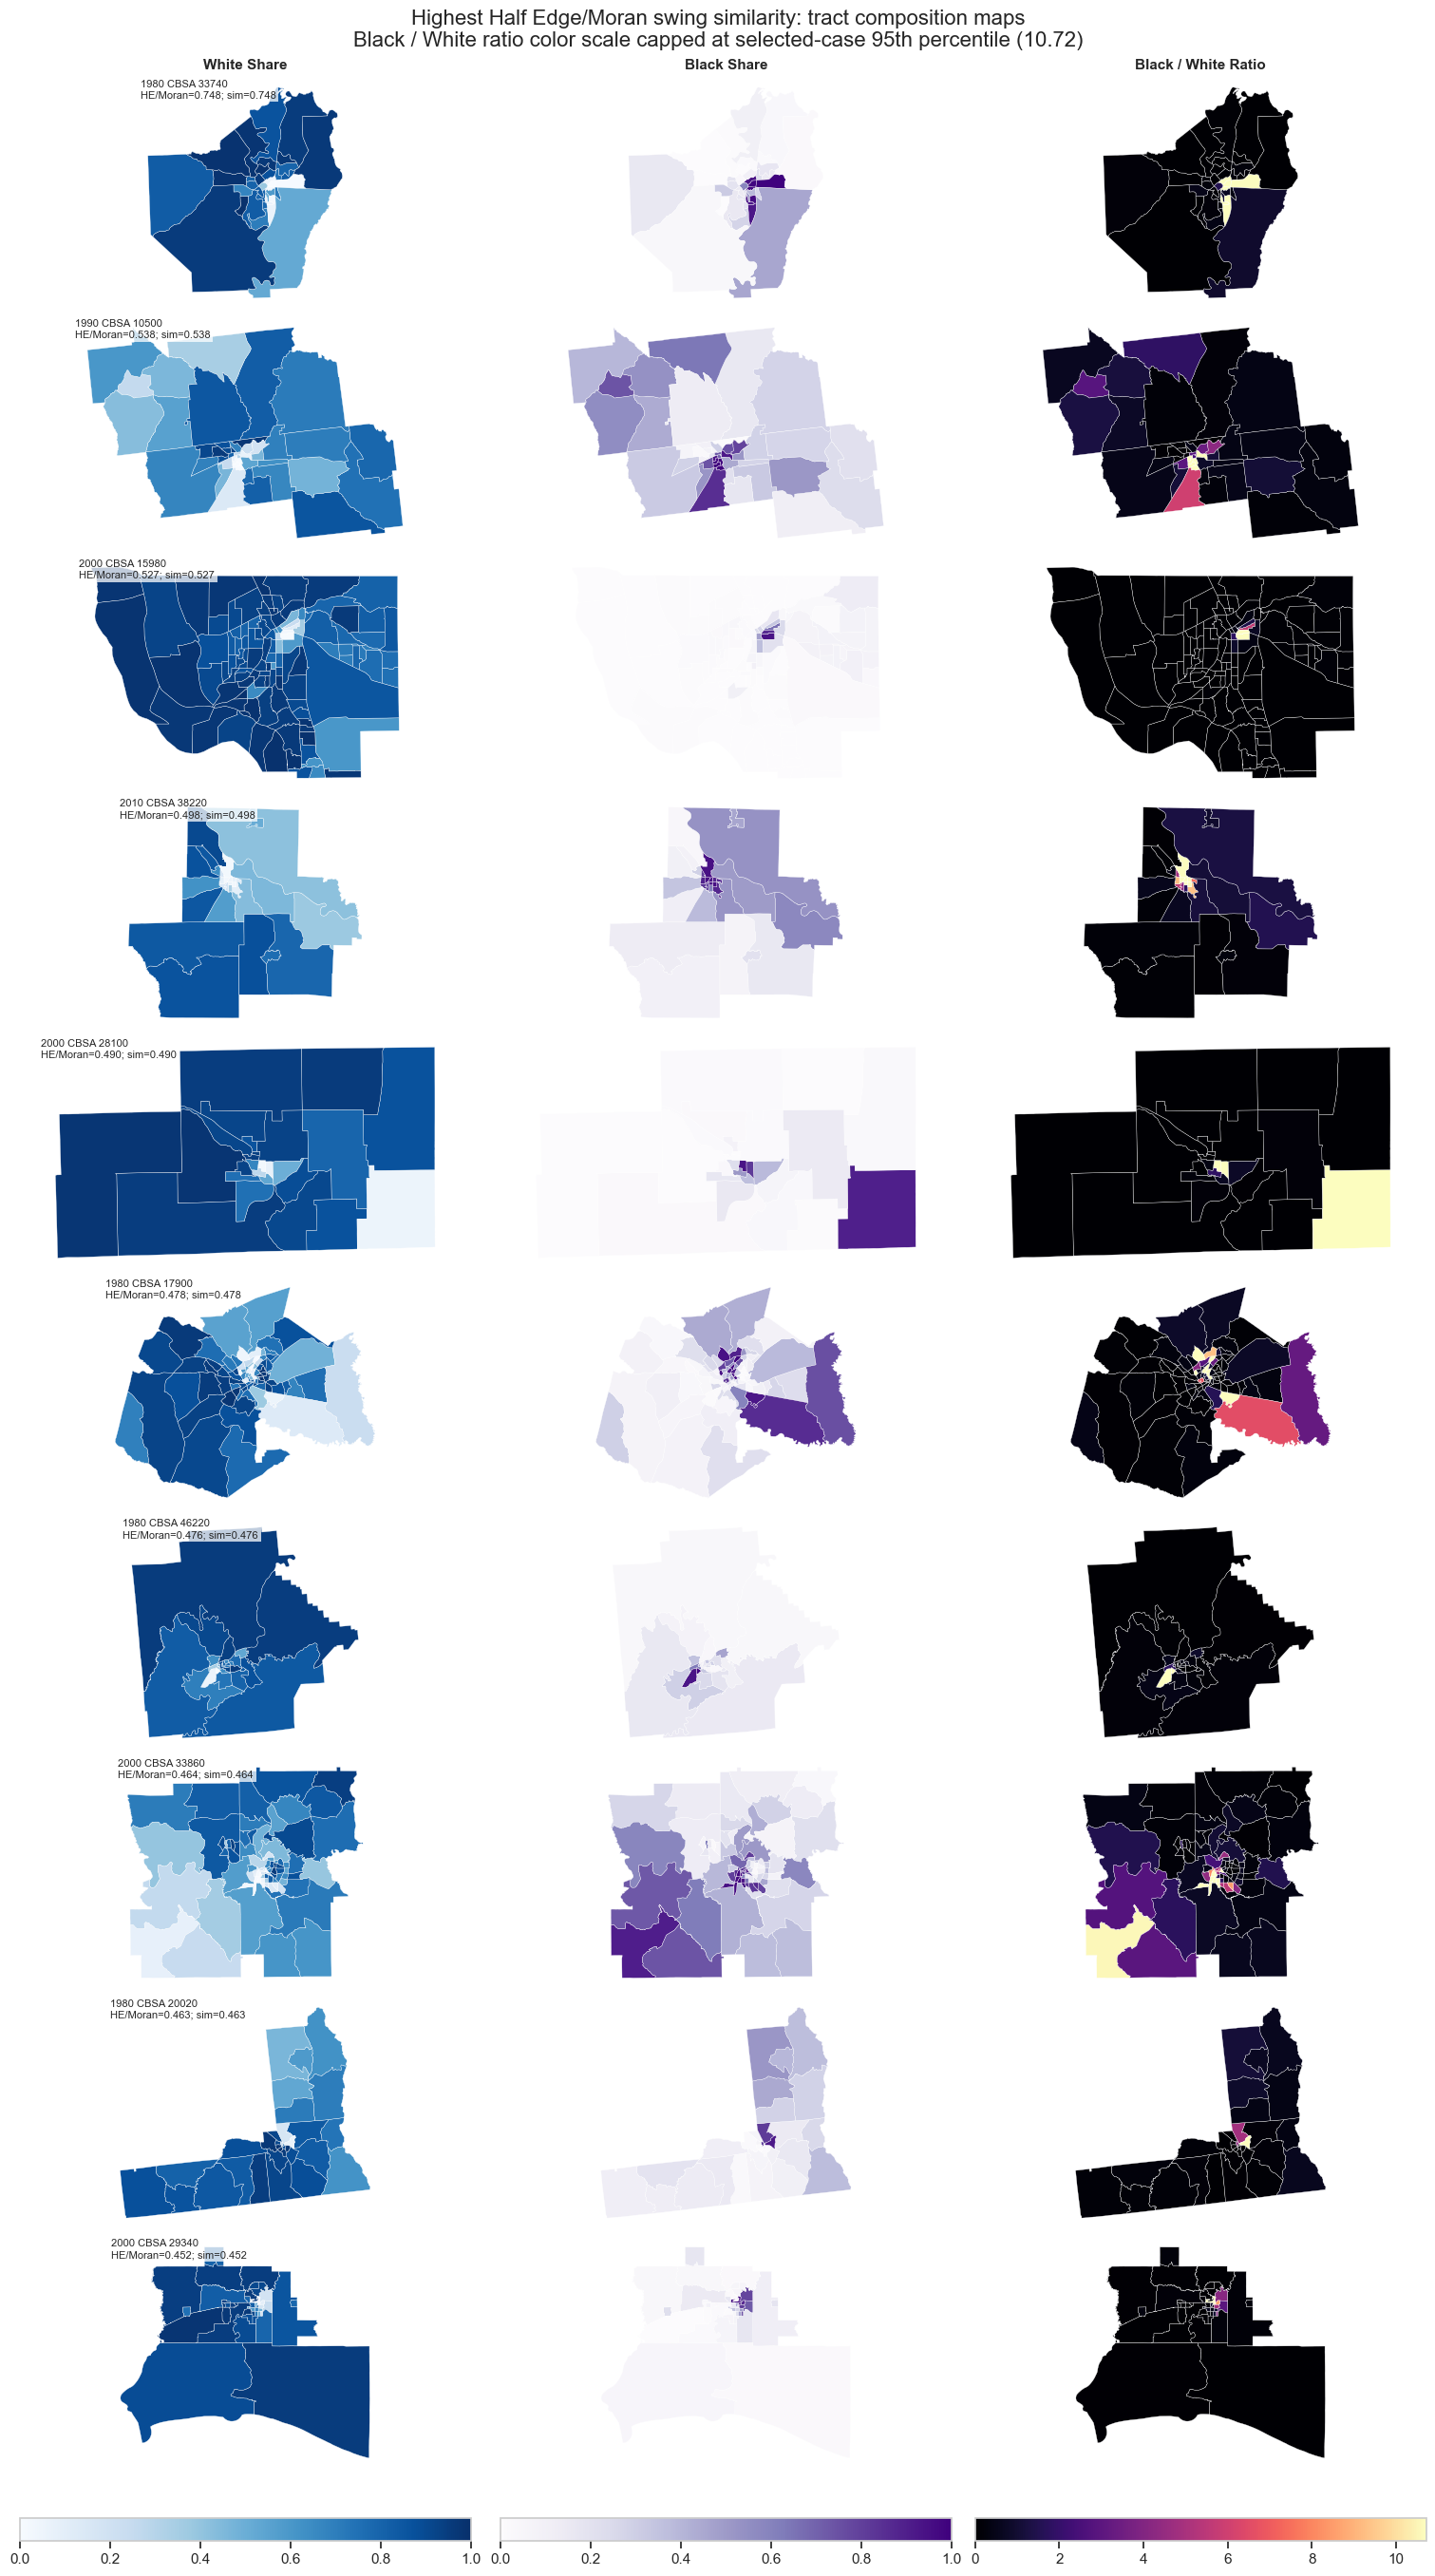

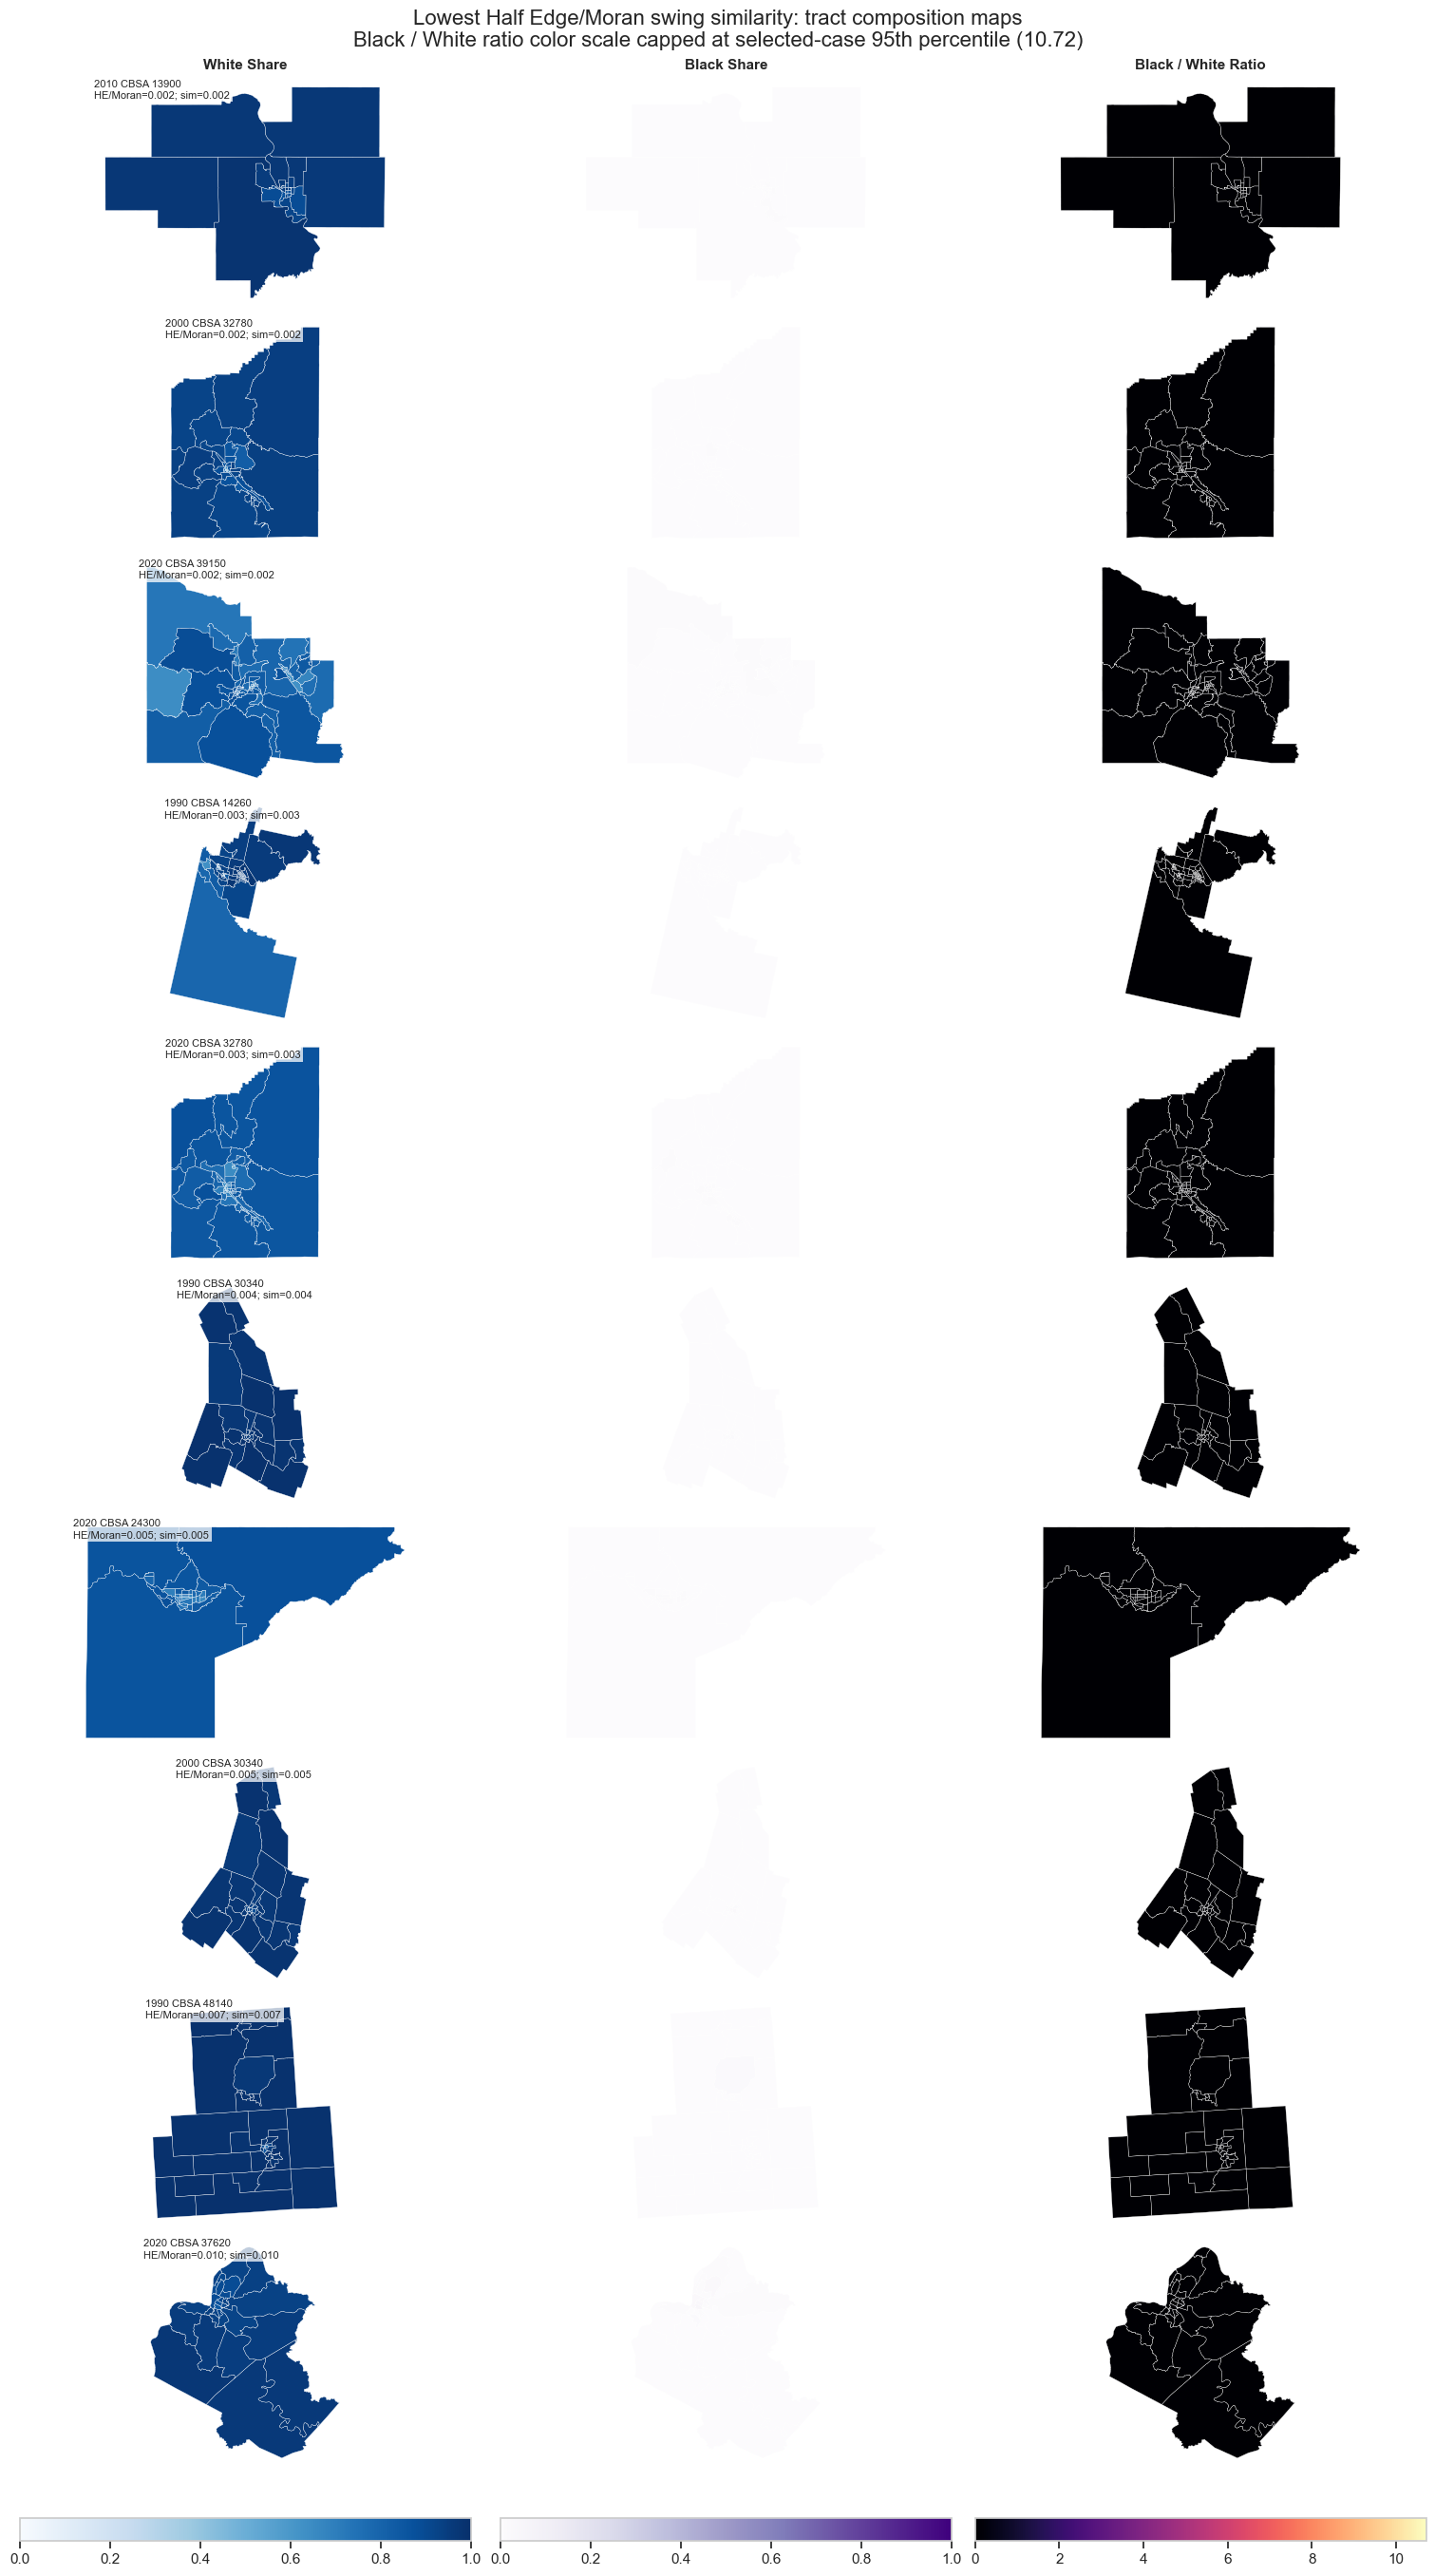

In [68]:
for group_name, group_cases in [
    ("Highest Half Edge/Moran swing similarity", top_10_cases),
    ("Lowest Half Edge/Moran swing similarity", bottom_10_cases),
]:
    group_keys = set(group_cases["area_key"])
    group_geographies = [entry for entry in case_geographies if entry["case"].area_key in group_keys]
    fig, axes = plt.subplots(
        nrows=len(group_geographies),
        ncols=len(map_columns),
        figsize=(15, max(4, 2.7 * len(group_geographies))),
        constrained_layout=True,
        squeeze=False,
    )

    for row_index, entry in enumerate(group_geographies):
        case = entry["case"]
        gdf = entry["gdf"]
        for col_index, column in enumerate(map_columns):
            ax = axes[row_index, col_index]
            settings = map_color_settings[column]
            gdf.plot(
                column=column,
                ax=ax,
                cmap=settings["cmap"],
                vmin=settings["vmin"],
                vmax=settings["vmax"],
                legend=False,
                edgecolor="white",
                linewidth=0.25,
                missing_kwds={"color": "lightgrey", "label": "Missing"},
            )
            ax.set_axis_off()
            if row_index == 0:
                ax.set_title(map_titles[column], fontsize=11, fontweight="bold")
            if col_index == 0:
                ax.text(
                    0.01,
                    0.99,
                    f"{case.area_key}\nHE/Moran={case.he_to_moran_spread_ratio:.3f}; sim={case.spread_similarity:.3f}",
                    transform=ax.transAxes,
                    va="top",
                    ha="left",
                    fontsize=8,
                    bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.75, "pad": 2},
                )

    for col_index, column in enumerate(map_columns):
        settings = map_color_settings[column]
        scalar_mappable = plt.cm.ScalarMappable(
            cmap=settings["cmap"],
            norm=plt.Normalize(vmin=settings["vmin"], vmax=settings["vmax"]),
        )
        scalar_mappable.set_array([])
        fig.colorbar(
            scalar_mappable,
            ax=axes[:, col_index],
            orientation="horizontal",
            fraction=0.035,
            pad=0.02,
        )

    fig.suptitle(
        f"{group_name}: tract composition maps\nBlack / White ratio color scale capped at selected-case 95th percentile ({ratio_color_max:.2f})",
        fontsize=16,
    )
    plt.show()

## Half Edge within/between decomposition

This diagnostic replays the same composition-placement permutations and records the raw `angle_1` diagonal and edge products. With `lambda=1`, the within-tract products are fixed by the composition multiset; only the between-tract edge products move with placement.

In [69]:
decomposition_rng = np.random.default_rng(RANDOM_SEED)
decomposition_records = []
area_heterogeneity_records = []
composition_columns = [X_COL, Y_COL, TOT_COL]

if "project_root" not in globals():
    for candidate_root in [Path.cwd(), *Path.cwd().parents]:
        if (candidate_root / "pipeline" / "calculate_metrics.py").exists():
            project_root = candidate_root
            break
    else:
        raise FileNotFoundError("Could not find the project root")

for area in sample_rows.itertuples(index=False):
    graph = gerrychain.Graph.from_json(project_root / area.filename)
    node_order = list(graph.nodes())
    compositions = [
        {column: int(graph.nodes[node][column]) for column in composition_columns}
        for node in node_order
    ]

    black_counts = np.array([composition[X_COL] for composition in compositions], dtype=float)
    white_counts = np.array([composition[Y_COL] for composition in compositions], dtype=float)
    total_counts = np.array([composition[TOT_COL] for composition in compositions], dtype=float)
    valid_total = total_counts > 0
    black_shares = np.divide(
        black_counts,
        total_counts,
        out=np.full_like(black_counts, np.nan),
        where=valid_total,
    )

    area_heterogeneity_records.append(
        {
            "area_key": area.area_key,
            "black_count_mean": black_counts.mean(),
            "black_count_var": black_counts.var(ddof=0),
            "black_count_cv": black_counts.std(ddof=1) / black_counts.mean()
            if len(black_counts) > 1 and black_counts.mean() > 0
            else np.nan,
            "white_count_cv": white_counts.std(ddof=1) / white_counts.mean()
            if len(white_counts) > 1 and white_counts.mean() > 0
            else np.nan,
            "total_pop_cv": total_counts.std(ddof=1) / total_counts.mean()
            if len(total_counts) > 1 and total_counts.mean() > 0
            else np.nan,
            "black_share_mean": np.nanmean(black_shares),
            "black_share_cv": np.nanstd(black_shares, ddof=1) / np.nanmean(black_shares)
            if np.isfinite(np.nanmean(black_shares)) and np.nanmean(black_shares) > 0
            else np.nan,
            "black_count_second_moment": np.mean(black_counts**2),
        }
    )

    for permutation in range(-1, N_PERMUTATIONS):
        if permutation == -1:
            placement_graph = graph
            placement = "observed"
            is_observed = True
        else:
            placement_graph = graph.copy()
            shuffled_indices = decomposition_rng.permutation(len(node_order))
            for node, composition_index in zip(node_order, shuffled_indices):
                for column, value in compositions[composition_index].items():
                    placement_graph.nodes[node][column] = value
            placement = "permuted"
            is_observed = False

        within_xx = within_xy = within_yy = 0.0
        for node in placement_graph.nodes():
            x = int(placement_graph.nodes[node][X_COL])
            y = int(placement_graph.nodes[node][Y_COL])
            within_xx += x * x
            within_xy += x * y
            within_yy += y * y

        between_xx = between_xy = between_yy = 0.0
        for node, neighbor in placement_graph.edges():
            x_node = int(placement_graph.nodes[node][X_COL])
            y_node = int(placement_graph.nodes[node][Y_COL])
            x_neighbor = int(placement_graph.nodes[neighbor][X_COL])
            y_neighbor = int(placement_graph.nodes[neighbor][Y_COL])
            between_xx += x_node * x_neighbor + x_neighbor * x_node
            between_xy += x_node * y_neighbor + x_neighbor * y_node
            between_yy += y_node * y_neighbor + y_neighbor * y_node

        xx_angle_1 = within_xx + between_xx
        xy_angle_1 = within_xy + between_xy
        yy_angle_1 = within_yy + between_yy
        within_total = within_xx + within_yy + (2 * within_xy)
        between_total = between_xx + between_yy + (2 * between_xy)

        decomposition_records.append(
            {
                "area_key": area.area_key,
                "placement": placement,
                "permutation": permutation,
                "is_observed": is_observed,
                "within_xx": within_xx,
                "within_xy": within_xy,
                "within_yy": within_yy,
                "between_xx": between_xx,
                "between_xy": between_xy,
                "between_yy": between_yy,
                "within_total": within_total,
                "between_total": between_total,
                "half_edge_rebuilt": 0.5
                * ((xx_angle_1 / (xx_angle_1 + xy_angle_1)) + (yy_angle_1 / (yy_angle_1 + xy_angle_1))),
            }
        )

half_edge_decomposition = pd.DataFrame(decomposition_records)
area_heterogeneity = pd.DataFrame(area_heterogeneity_records)

decomposition_check = half_edge_decomposition.merge(
    results[["area_key", "placement", "permutation", "half_edge_lam_1_angle_1"]],
    on=["area_key", "placement", "permutation"],
    how="left",
    validate="one_to_one",
)
max_half_edge_rebuild_error = (
    decomposition_check["half_edge_rebuilt"] - decomposition_check["half_edge_lam_1_angle_1"]
).abs().max()
if max_half_edge_rebuild_error > 1e-10:
    raise ValueError(f"Half Edge decomposition check failed: {max_half_edge_rebuild_error}")

half_edge_decomposition.shape

(50100, 13)

In [70]:
permuted_decomposition = half_edge_decomposition[~half_edge_decomposition["is_observed"]]
observed_decomposition = half_edge_decomposition[half_edge_decomposition["is_observed"]].set_index("area_key")

between_summary = (
    permuted_decomposition.groupby("area_key")
    .agg(
        between_xx_mean=("between_xx", "mean"),
        between_xy_mean=("between_xy", "mean"),
        between_yy_mean=("between_yy", "mean"),
        between_total_mean=("between_total", "mean"),
        between_total_sd=("between_total", "std"),
        half_edge_rebuilt_sd=("half_edge_rebuilt", "std"),
    )
    .reset_index()
)

within_diagnostics = (
    observed_decomposition[
        [
            "within_xx",
            "within_xy",
            "within_yy",
            "within_total",
            "between_total",
        ]
    ]
    .rename(columns={"between_total": "observed_between_total"})
    .reset_index()
    .merge(between_summary, on="area_key", how="left", validate="one_to_one")
    .merge(area_heterogeneity, on="area_key", how="left", validate="one_to_one")
    .merge(spread_wide, on="area_key", how="left", validate="one_to_one")
)

within_diagnostics["within_total_share_perm_mean"] = within_diagnostics["within_total"] / (
    within_diagnostics["within_total"] + within_diagnostics["between_total_mean"]
)
within_diagnostics["within_total_share_observed"] = within_diagnostics["within_total"] / (
    within_diagnostics["within_total"] + within_diagnostics["observed_between_total"]
)
within_diagnostics["within_xx_share_perm_mean"] = within_diagnostics["within_xx"] / (
    within_diagnostics["within_xx"] + within_diagnostics["between_xx_mean"]
)
within_diagnostics["within_xy_share_perm_mean"] = within_diagnostics["within_xy"] / (
    within_diagnostics["within_xy"] + within_diagnostics["between_xy_mean"]
)
within_diagnostics["within_yy_share_perm_mean"] = within_diagnostics["within_yy"] / (
    within_diagnostics["within_yy"] + within_diagnostics["between_yy_mean"]
)
within_diagnostics["between_total_cv"] = within_diagnostics["between_total_sd"] / within_diagnostics[
    "between_total_mean"
]
within_diagnostics["similarity_tail"] = "middle sampled areas"
within_diagnostics.loc[
    within_diagnostics["area_key"].isin(top_10_cases["area_key"]), "similarity_tail"
] = "highest similarity"
within_diagnostics.loc[
    within_diagnostics["area_key"].isin(bottom_10_cases["area_key"]), "similarity_tail"
] = "lowest similarity"

within_diagnostic_columns = [
    "area_key",
    "similarity_tail",
    "total_x",
    "black_count_cv",
    "black_share_cv",
    "total_pop_cv",
    "within_total_share_perm_mean",
    "within_xx_share_perm_mean",
    "within_xy_share_perm_mean",
    "within_yy_share_perm_mean",
    "between_total_cv",
    "half_edge_spread",
    "moran_spread",
    "he_to_moran_spread_ratio",
    "spread_similarity",
]

within_diagnostics.sort_values("he_to_moran_spread_ratio")[within_diagnostic_columns].head(20)

,area_key,similarity_tail,total_x,black_count_cv,black_share_cv,total_pop_cv,within_total_share_perm_mean,within_xx_share_perm_mean,within_xy_share_perm_mean,within_yy_share_perm_mean,between_total_cv,half_edge_spread,moran_spread,he_to_moran_spread_ratio,spread_similarity
56,2010 CBSA 13900,lowest similarity,0.005342,0.746777,0.723446,0.361965,0.182282,0.236694,0.182113,0.182282,0.040765,0.000132,0.056285,0.002342,0.002342
49,2000 CBSA 32780,lowest similarity,0.003718,0.717014,0.796571,0.423116,0.181119,0.220445,0.164074,0.181259,0.039514,0.000113,0.046001,0.002446,0.002446
93,2020 CBSA 39150,lowest similarity,0.005990,0.841454,0.545482,0.517372,0.190666,0.242320,0.197656,0.190554,0.054761,0.000079,0.032369,0.002452,0.002452
20,1990 CBSA 14260,lowest similarity,0.003517,0.971802,1.051650,0.418620,0.187618,0.272067,0.186658,0.187624,0.040932,0.000102,0.032153,0.003179,0.003179
89,2020 CBSA 32780,lowest similarity,0.007050,0.612292,0.630416,0.305549,0.169234,0.204697,0.163318,0.169339,0.028328,0.000131,0.040528,0.003238,0.003238
27,1990 CBSA 30340,lowest similarity,0.004399,1.063564,0.909966,0.419188,0.190426,0.305819,0.194153,0.190390,0.043239,0.000173,0.047401,0.003649,0.003649
82,2020 CBSA 24300,lowest similarity,0.006551,0.611310,0.733750,0.330696,0.182972,0.214814,0.165727,0.183257,0.043750,0.000178,0.036955,0.004808,0.004808
48,2000 CBSA 30340,lowest similarity,0.006234,0.993957,0.923868,0.424052,0.191065,0.287272,0.188163,0.191098,0.050825,0.000245,0.047799,0.005116,0.005116
38,1990 CBSA 48140,lowest similarity,0.001166,2.358641,2.453908,0.320929,0.182081,0.607056,0.169799,0.182109,0.041177,0.000125,0.019056,0.006571,0.006571
92,2020 CBSA 37620,lowest similarity,0.011420,0.952307,0.872000,0.378144,0.188860,0.282127,0.180963,0.189038,0.049404,0.000503,0.048454,0.010382,0.010382


In [71]:
decomposition_csv_path = project_root / "output_exploration" / "placement_permutations_decomposition.csv"
area_diagnostics_csv_path = project_root / "output_exploration" / "placement_permutations_area_diagnostics.csv"

half_edge_decomposition.to_csv(decomposition_csv_path, index=False)
within_diagnostics.to_csv(area_diagnostics_csv_path, index=False)

pd.DataFrame(
    [
        {
            "dataset": "placement-level decomposition",
            "path": decomposition_csv_path,
            "rows": len(half_edge_decomposition),
            "columns": half_edge_decomposition.shape[1],
        },
        {
            "dataset": "area-level regression diagnostics",
            "path": area_diagnostics_csv_path,
            "rows": len(within_diagnostics),
            "columns": within_diagnostics.shape[1],
        },
    ]
)

,dataset,path,rows,columns
0,placement-level decomposition,/Users/maria/Documents/capy-bara/output_explor...,50100,13
1,area-level regression diagnostics,/Users/maria/Documents/capy-bara/output_explor...,100,50


In [72]:
diagnostic_predictors = [
    "within_total_share_perm_mean",
    "within_total_share_observed",
    "within_xx_share_perm_mean",
    "within_xy_share_perm_mean",
    "within_yy_share_perm_mean",
    "between_total_cv",
    "black_count_cv",
    "black_share_cv",
    "total_pop_cv",
    "total_x",
    "edge_density",
]

correlation_rows = []
for method in ["pearson", "spearman"]:
    correlations = within_diagnostics[["he_to_moran_spread_ratio", *diagnostic_predictors]].corr(
        method=method
    )["he_to_moran_spread_ratio"]
    for predictor in diagnostic_predictors:
        correlation_rows.append(
            {
                "method": method,
                "predictor": predictor,
                "correlation_with_he_to_moran_spread_ratio": correlations[predictor],
            }
        )

within_correlation_table = pd.DataFrame(correlation_rows)
within_correlation_table.sort_values(
    ["method", "correlation_with_he_to_moran_spread_ratio"], ascending=[True, True]
)

,method,predictor,correlation_with_he_to_moran_spread_ratio
3,pearson,within_xy_share_perm_mean,-0.673925
10,pearson,edge_density,-0.057792
5,pearson,between_total_cv,-0.026452
7,pearson,black_share_cv,0.046640
0,pearson,within_total_share_perm_mean,0.130747
1,pearson,within_total_share_observed,0.151005
6,pearson,black_count_cv,0.183147
2,pearson,within_xx_share_perm_mean,0.189015
8,pearson,total_pop_cv,0.314486
4,pearson,within_yy_share_perm_mean,0.557377


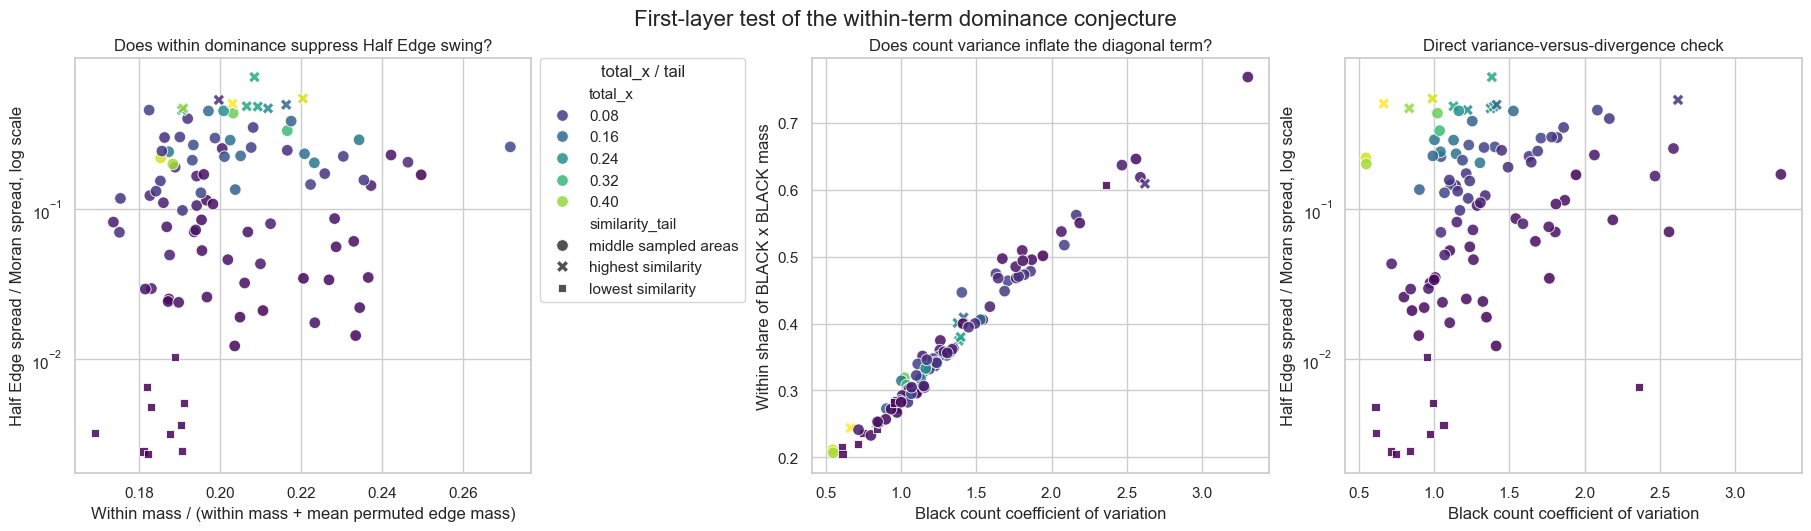

In [73]:
plot_within_diagnostics = within_diagnostics[
    within_diagnostics["he_to_moran_spread_ratio"].gt(0)
].copy()

fig, axes = plt.subplots(ncols=3, figsize=(18, 5.2), constrained_layout=True)

sns.scatterplot(
    data=plot_within_diagnostics,
    x="within_total_share_perm_mean",
    y="he_to_moran_spread_ratio",
    hue="total_x",
    style="similarity_tail",
    palette="viridis",
    s=70,
    alpha=0.85,
    ax=axes[0],
)
axes[0].set_yscale("log")
axes[0].set_xlabel("Within mass / (within mass + mean permuted edge mass)")
axes[0].set_ylabel("Half Edge spread / Moran spread, log scale")
axes[0].set_title("Does within dominance suppress Half Edge swing?")

sns.scatterplot(
    data=plot_within_diagnostics,
    x="black_count_cv",
    y="within_xx_share_perm_mean",
    hue="total_x",
    style="similarity_tail",
    palette="viridis",
    s=70,
    alpha=0.85,
    ax=axes[1],
)
axes[1].set_xlabel("Black count coefficient of variation")
axes[1].set_ylabel("Within share of BLACK x BLACK mass")
axes[1].set_title("Does count variance inflate the diagonal term?")

sns.scatterplot(
    data=plot_within_diagnostics,
    x="black_count_cv",
    y="he_to_moran_spread_ratio",
    hue="total_x",
    style="similarity_tail",
    palette="viridis",
    s=70,
    alpha=0.85,
    ax=axes[2],
)
axes[2].set_yscale("log")
axes[2].set_xlabel("Black count coefficient of variation")
axes[2].set_ylabel("Half Edge spread / Moran spread, log scale")
axes[2].set_title("Direct variance-versus-divergence check")

for ax in axes[1:]:
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()

axes[0].legend(title="total_x / tail", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
fig.suptitle("First-layer test of the within-term dominance conjecture", fontsize=16)
plt.show()